# Experiment 1: CT, SD & Decision Carryover Analysis

Merged from previous notebooks. Covers:
- Central Tendency (CTI)
- Serial Dependence (SDI)
- Decision Carryover


In [1]:
import sys
sys.path.insert(0, '../../shared')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import sem, ttest_rel, ttest_ind, ttest_1samp
from scipy.optimize import curve_fit
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pingouin as pg
import warnings
from itertools import combinations
from plot_config import set_nature_style, COLORS, TRANSITION_ORDER, TRANSITION_PALETTE, despine
set_nature_style()
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Load Data

In [2]:
df = pd.read_pickle("E1.pkl")
df = df[df["is_outlier"] == False].copy()
print(f"Loaded {len(df)} trials, {df['subID'].nunique()} subjects")
print(f"Conditions: {df['TransitionType'].unique()}")

Loaded 4670 trials, 22 subjects
Conditions: <ArrowStringArray>
['LH', 'HH', 'HL', 'LL']
Length: 4, dtype: string


## Analysis

In [3]:
def fit_mixedlm_for_U(df, U_col, dv="bias_log", dur_col="log_cur_c", sub_col="NSub"):
    """
     U ， MixedLM：
    - model_main: dv ~ dur + U
    - model_inter: dv ~ dur * U
     summary 。
    """
    df = df.dropna(subset=[dv, dur_col, U_col, sub_col]).copy()
    U_mean = df[U_col].mean()
    U_std = df[U_col].std()
    df[f"{U_col}_z"] = (df[U_col] - U_mean) / (U_std if U_std > 0 else 1.0)
    U_z = f"{U_col}_z"
    formula_main = f"{dv} ~ {dur_col} + {U_z}"
    model_main = smf.mixedlm(formula_main, df, groups=df[sub_col])
    result_main = model_main.fit(method="lbfgs")
    formula_inter = f"{dv} ~ {dur_col} * {U_z}"
    model_inter = smf.mixedlm(formula_inter, df, groups=df[sub_col])
    result_inter = model_inter.fit(method="lbfgs")
    inter_term = f"{dur_col}:{U_z}"
    if inter_term in result_inter.params.index:
        p_inter = result_inter.pvalues[inter_term]
        beta_inter = result_inter.params[inter_term]
    else:
        p_inter = np.nan
        beta_inter = np.nan
    summary = {
        "U_col": U_col,
        "AIC_main": result_main.aic,
        "AIC_inter": result_inter.aic,
        "delta_AIC": result_inter.aic - result_main.aic,
        "beta_U_main": result_main.params.get(U_z, np.nan),
        "p_U_main": result_main.pvalues.get(U_z, np.nan),
        "beta_inter": beta_inter,
        "p_inter": p_inter,
    }
    return result_main, result_inter, summary


In [4]:
def run_all_U_models(df):
    """
     U_full, U_early, U_late, U_thresh_time ，
     summary_df。
    """
    U_cols = ["U_full", "U_early", "U_late", "U_thresh_time"]
    summaries = []
    for col in U_cols:
        if col not in df.columns:
            continue
        _, _, summ = fit_mixedlm_for_U(df, U_col=col)
        summaries.append(summ)
    summary_df = pd.DataFrame(summaries)
    return summary_df


In [5]:
# group by Subject and current duration
df1= df.groupby(['subID', 'curDur']).curBias.mean().reset_index()
# set suject as ramdom effect
model = smf.mixedlm("curBias ~ curDur", df1, groups=df1['subID'])
result = model.fit()


In [6]:
def rmANOVA_gg_Long(data, dv, within, subject):
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)
        if len(within) == 1:
            GGpass = pg.sphericity(data, dv=dv, subject=subject, within=within, method='greenhouse-geisser')[0]
            aov = pg.rm_anova(data=data, dv=dv, within=within, subject=subject, detailed=True, effsize="np2", correction=not GGpass)
            if not GGpass:
                aov['DF-GG-corr'] = aov['DF'] * aov['eps'][0]
                aov.drop(columns=['sphericity', 'W_spher', 'p_spher'], inplace=True)
            return aov
        elif len(within) == 2:
            GGpass = pd.Series([True, True, True])
            factorDict = {"0": within[0], "1": within[1], "2": within}
            for i in range(3):
                GGpass[i] = pg.sphericity(data, dv=dv, subject=subject, within=factorDict[str(i)], method='greenhouse-geisser')[0]
                if not GGpass[i]:
                    pass  # placeholder
            aov = pg.rm_anova(data=data, dv=dv, within=within, subject=subject, detailed=True, effsize="np2", correction=True)
            eps = pd.Series([1, 1, 1])
            GGcrr = [not x for x in GGpass]
            eps[GGcrr] = aov['eps'][GGcrr]
            aov['DF1-GGcrr'] = aov['ddof1'] * eps
            aov['DF2-GGcrr'] = aov['ddof2'] * eps
            return aov
def apply_bonferroni(test_result_dict, panel_name):
    def extract_current_group(comp):
        try:
            c1, c2 = comp.split(' vs ')
            g1, g2 = c1.split('-')[1], c2.split('-')[1]
            return f'Current {g1.upper()}' if g1 == g2 else 'Mixed'
        except:
            return 'Unknown'
    df = pd.DataFrame([{
        'Panel': panel_name,
        'Comparison': k,
        't-value': v['t'],
        'p_uncorrected': v['p']
    } for k, v in test_result_dict.items()])
    df['p-bonferroni'] = (df['p_uncorrected'] * len(df)).clip(upper=1.0)
    df['Significance'] = df['p-bonferroni'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.')
    df['CurrentGroup'] = df['Comparison'].apply(extract_current_group)
    return df

# Set prior and current columns
df['prior'] = df['preCoherence1back']
df['current'] = df['curCoherence']

# Create df_ct by fitting OLS for each subject, prior, current combination
results = []
for (sub_id, prior, current), subdf in df.groupby(['subID', 'prior', 'current']):
    if subdf['curDur'].nunique() >= 3:
        X = sm.add_constant(subdf['curDur'])
        y = subdf['curBias']
        model = sm.OLS(y, X).fit()
        slope = model.params['curDur']
        intercept = model.params['const']
        results.append({
            'subID': sub_id,
            'prior': prior,
            'current': current,
            'ct_index': abs(slope),     
            'intercept': intercept
        })
df_ct = pd.DataFrame(results)

aov_cti = rmANOVA_gg_Long(data=df_ct, dv='ct_index', within=['prior', 'current'], subject='subID')
aov_bias = rmANOVA_gg_Long(data=df_ct, dv='intercept', within=['prior', 'current'], subject='subID')
summary_stats = df_ct.groupby(['prior', 'current']).agg(
    CTI_mean=('ct_index', 'mean'),
    CTI_sem=('ct_index', 'sem'),
    Bias_mean=('intercept', 'mean'),
    Bias_sem=('intercept', 'sem'),
    N=('subID', 'nunique')
).reset_index()
df_ct['SameSwitch'] = df_ct.apply(lambda row: 'Same' if row['prior'] == row['current'] else 'Switch', axis=1)
summary_same_switch = df_ct.groupby('SameSwitch').agg(
    CTI_mean=('ct_index', 'mean'),
    CTI_sem=('ct_index', 'sem'),
    Bias_mean=('intercept', 'mean'),
    Bias_sem=('intercept', 'sem'),
    N=('subID', 'nunique')
).reset_index()
df_ct['CurrentGroup'] = df_ct['current'].map({'High': 'High', 'Low': 'Low'})
df_ct_mean = df_ct.groupby(['subID', 'CurrentGroup']).agg(
    CTI=('ct_index', 'mean'),
    Bias=('intercept', 'mean')
).reset_index()
cti_H = df_ct_mean[df_ct_mean['CurrentGroup'] == 'High'].sort_values('subID')['CTI'].values
cti_L = df_ct_mean[df_ct_mean['CurrentGroup'] == 'Low'].sort_values('subID')['CTI'].values
bias_H = df_ct_mean[df_ct_mean['CurrentGroup'] == 'High'].sort_values('subID')['Bias'].values
bias_L = df_ct_mean[df_ct_mean['CurrentGroup'] == 'Low'].sort_values('subID')['Bias'].values
t_cti, p_cti = stats.ttest_rel(cti_H, cti_L)
t_bias, p_bias = stats.ttest_rel(bias_H, bias_L)
cti_H_mean, cti_H_sem = np.mean(cti_H), sem(cti_H)
cti_L_mean, cti_L_sem = np.mean(cti_L), sem(cti_L)
bias_H_mean, bias_H_sem = np.mean(bias_H), sem(bias_H)
bias_L_mean, bias_L_sem = np.mean(bias_L), sem(bias_L)


In [7]:
df['prior'] = df['preCoherence1back']
df['current'] = df['curCoherence']
df_summary = df.groupby(['subID', 'prior', 'current']).agg(
    SD=('curBias', 'std'),        
    RT=('rpr', 'mean')            
).reset_index()
aov_sd = rmANOVA_gg_Long(data=df_summary, dv='SD', within=['prior', 'current'], subject='subID')
aov_rt = rmANOVA_gg_Long(data=df_summary, dv='RT', within=['prior', 'current'], subject='subID')


## Figures

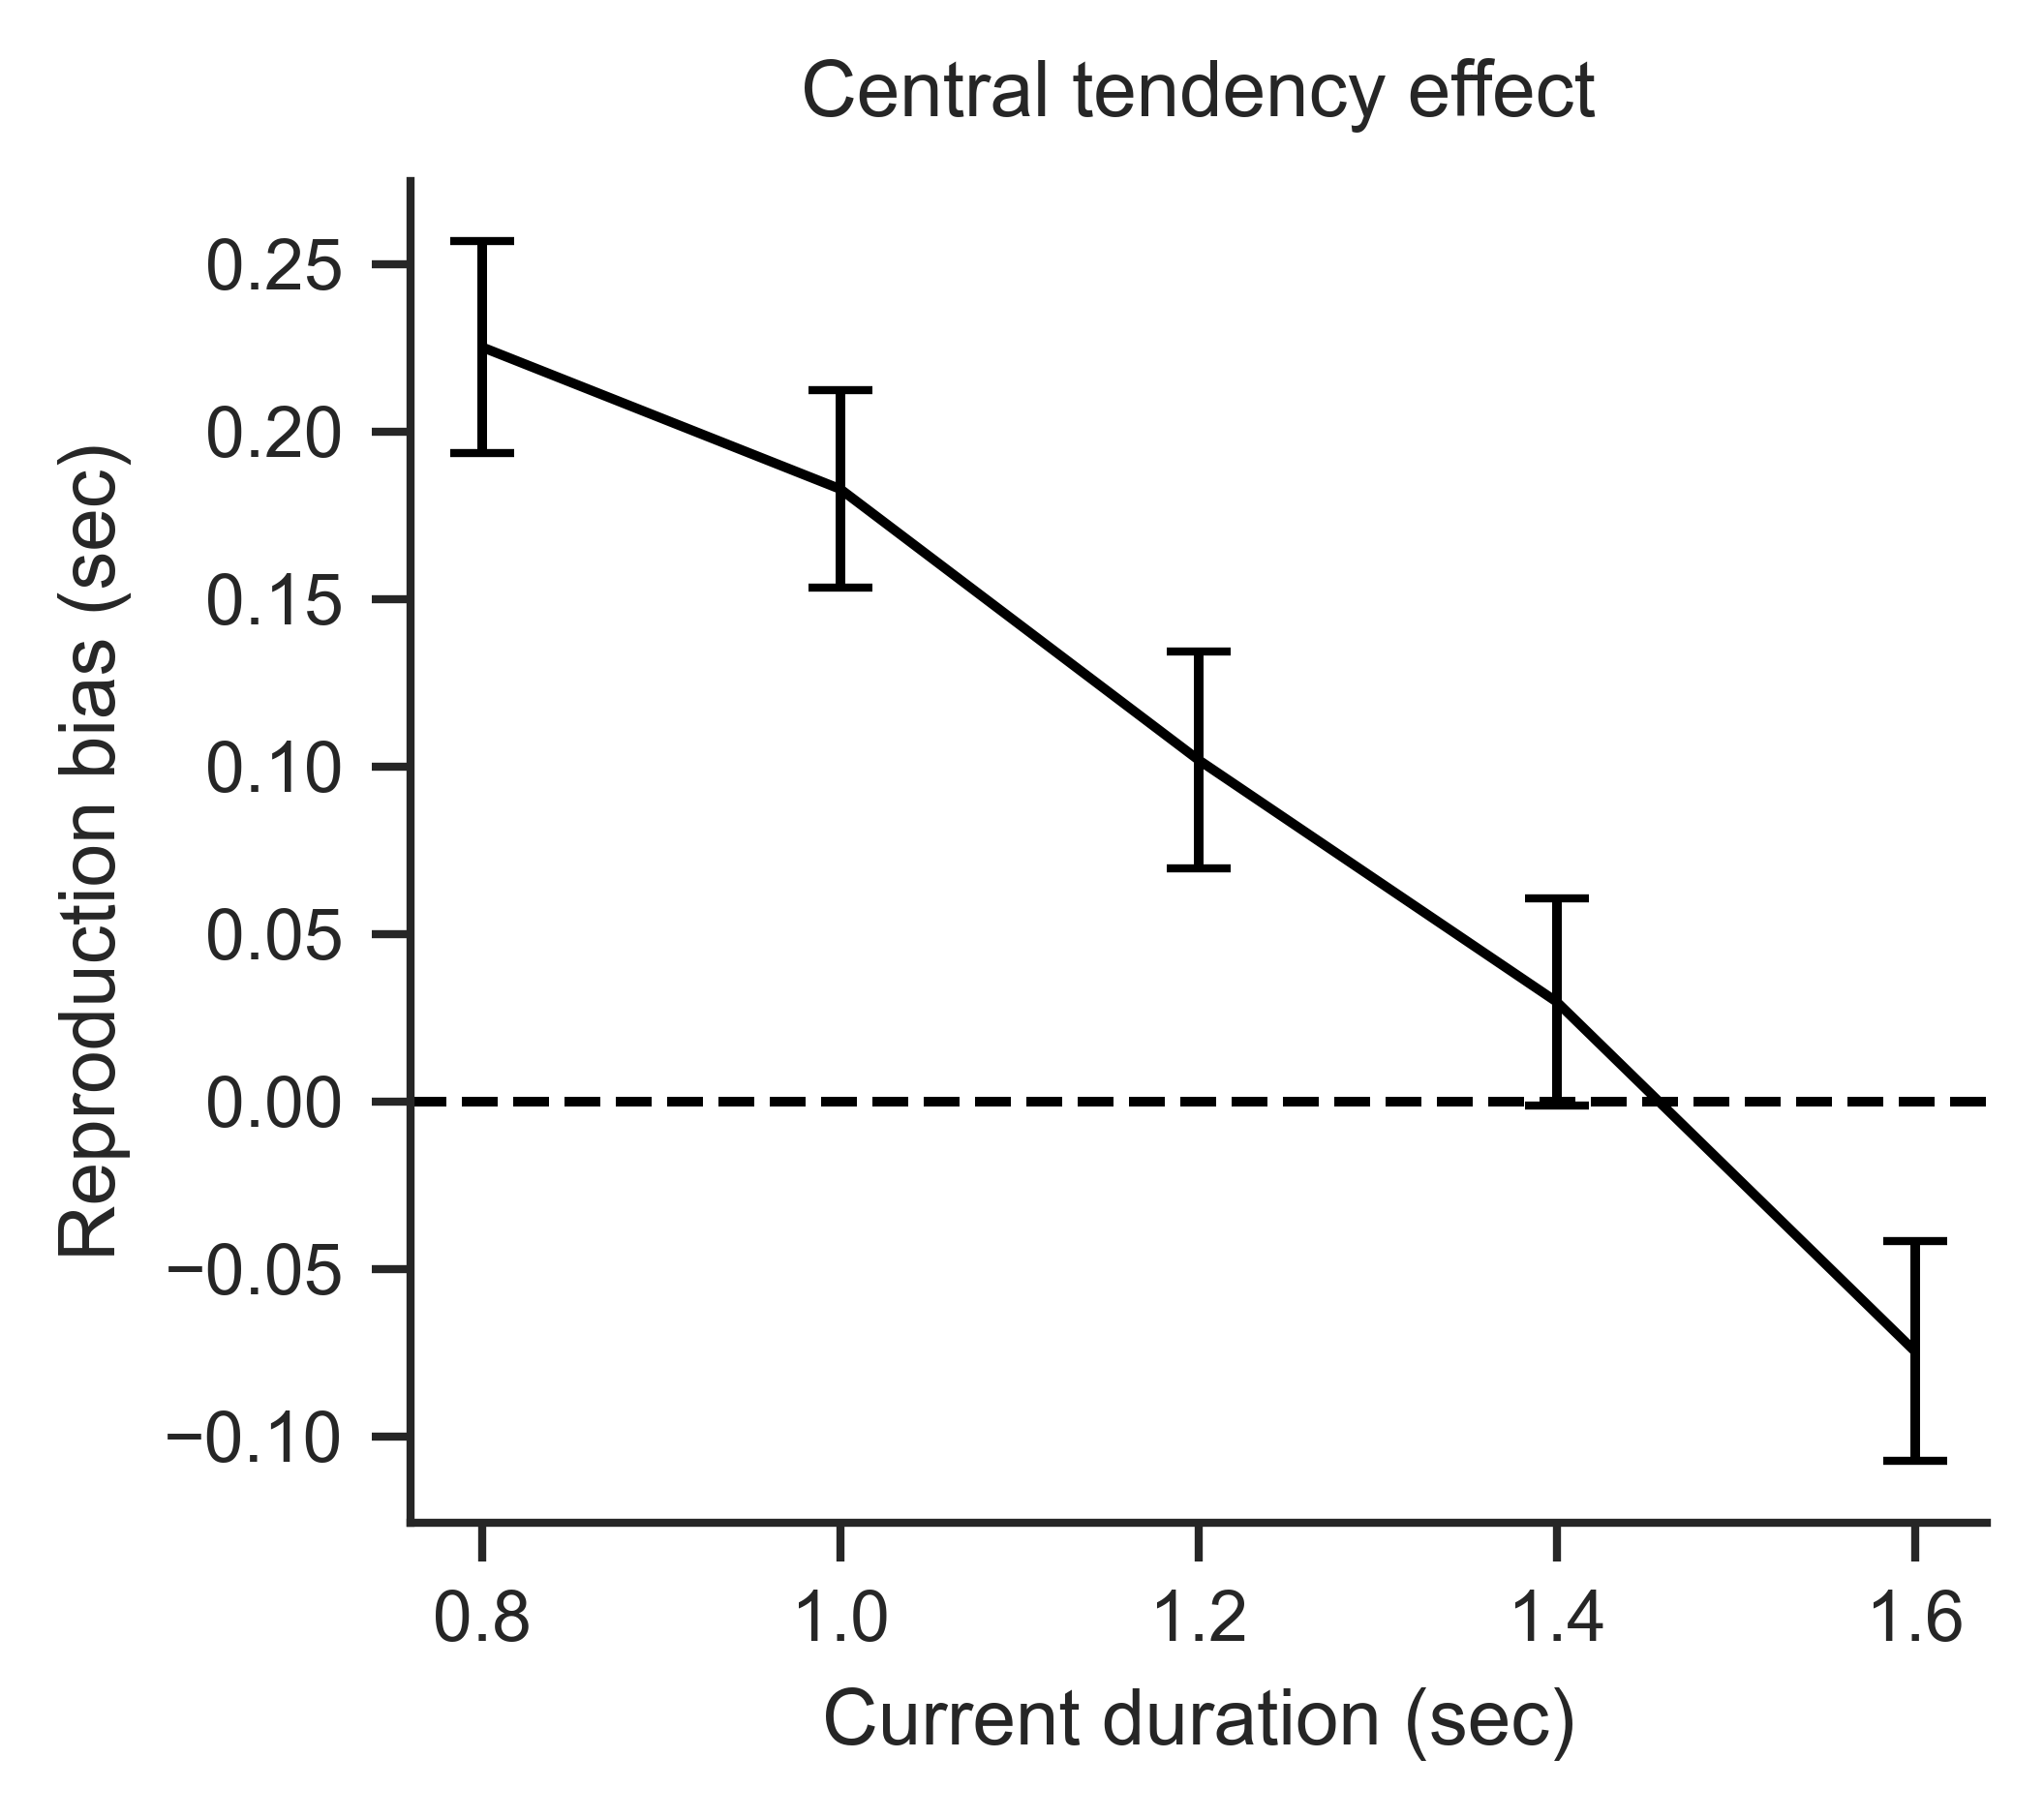

In [8]:
# Central tendency based on Reproduction Bias
mBiasDurPar = df.groupby(['subID', 'curDur']).curBias.mean().reset_index()
mBiasDurAll = mBiasDurPar.groupby('curDur').\
    agg({"curBias":["count","mean","sem"]}).reset_index()
mBiasDurAll.columns = ['curDur', 'count', 'mBias','seBias']
# plot central tendency
fig, ax = plt.subplots()
plt.errorbar(x='curDur', y='mBias', yerr='seBias', data=mBiasDurAll, 
             color='black', capsize=4)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(mBiasDurAll.curDur)
plt.xlabel('Current duration (sec)')
plt.ylabel('Reproduction bias (sec)')
plt.title('Central tendency effect')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

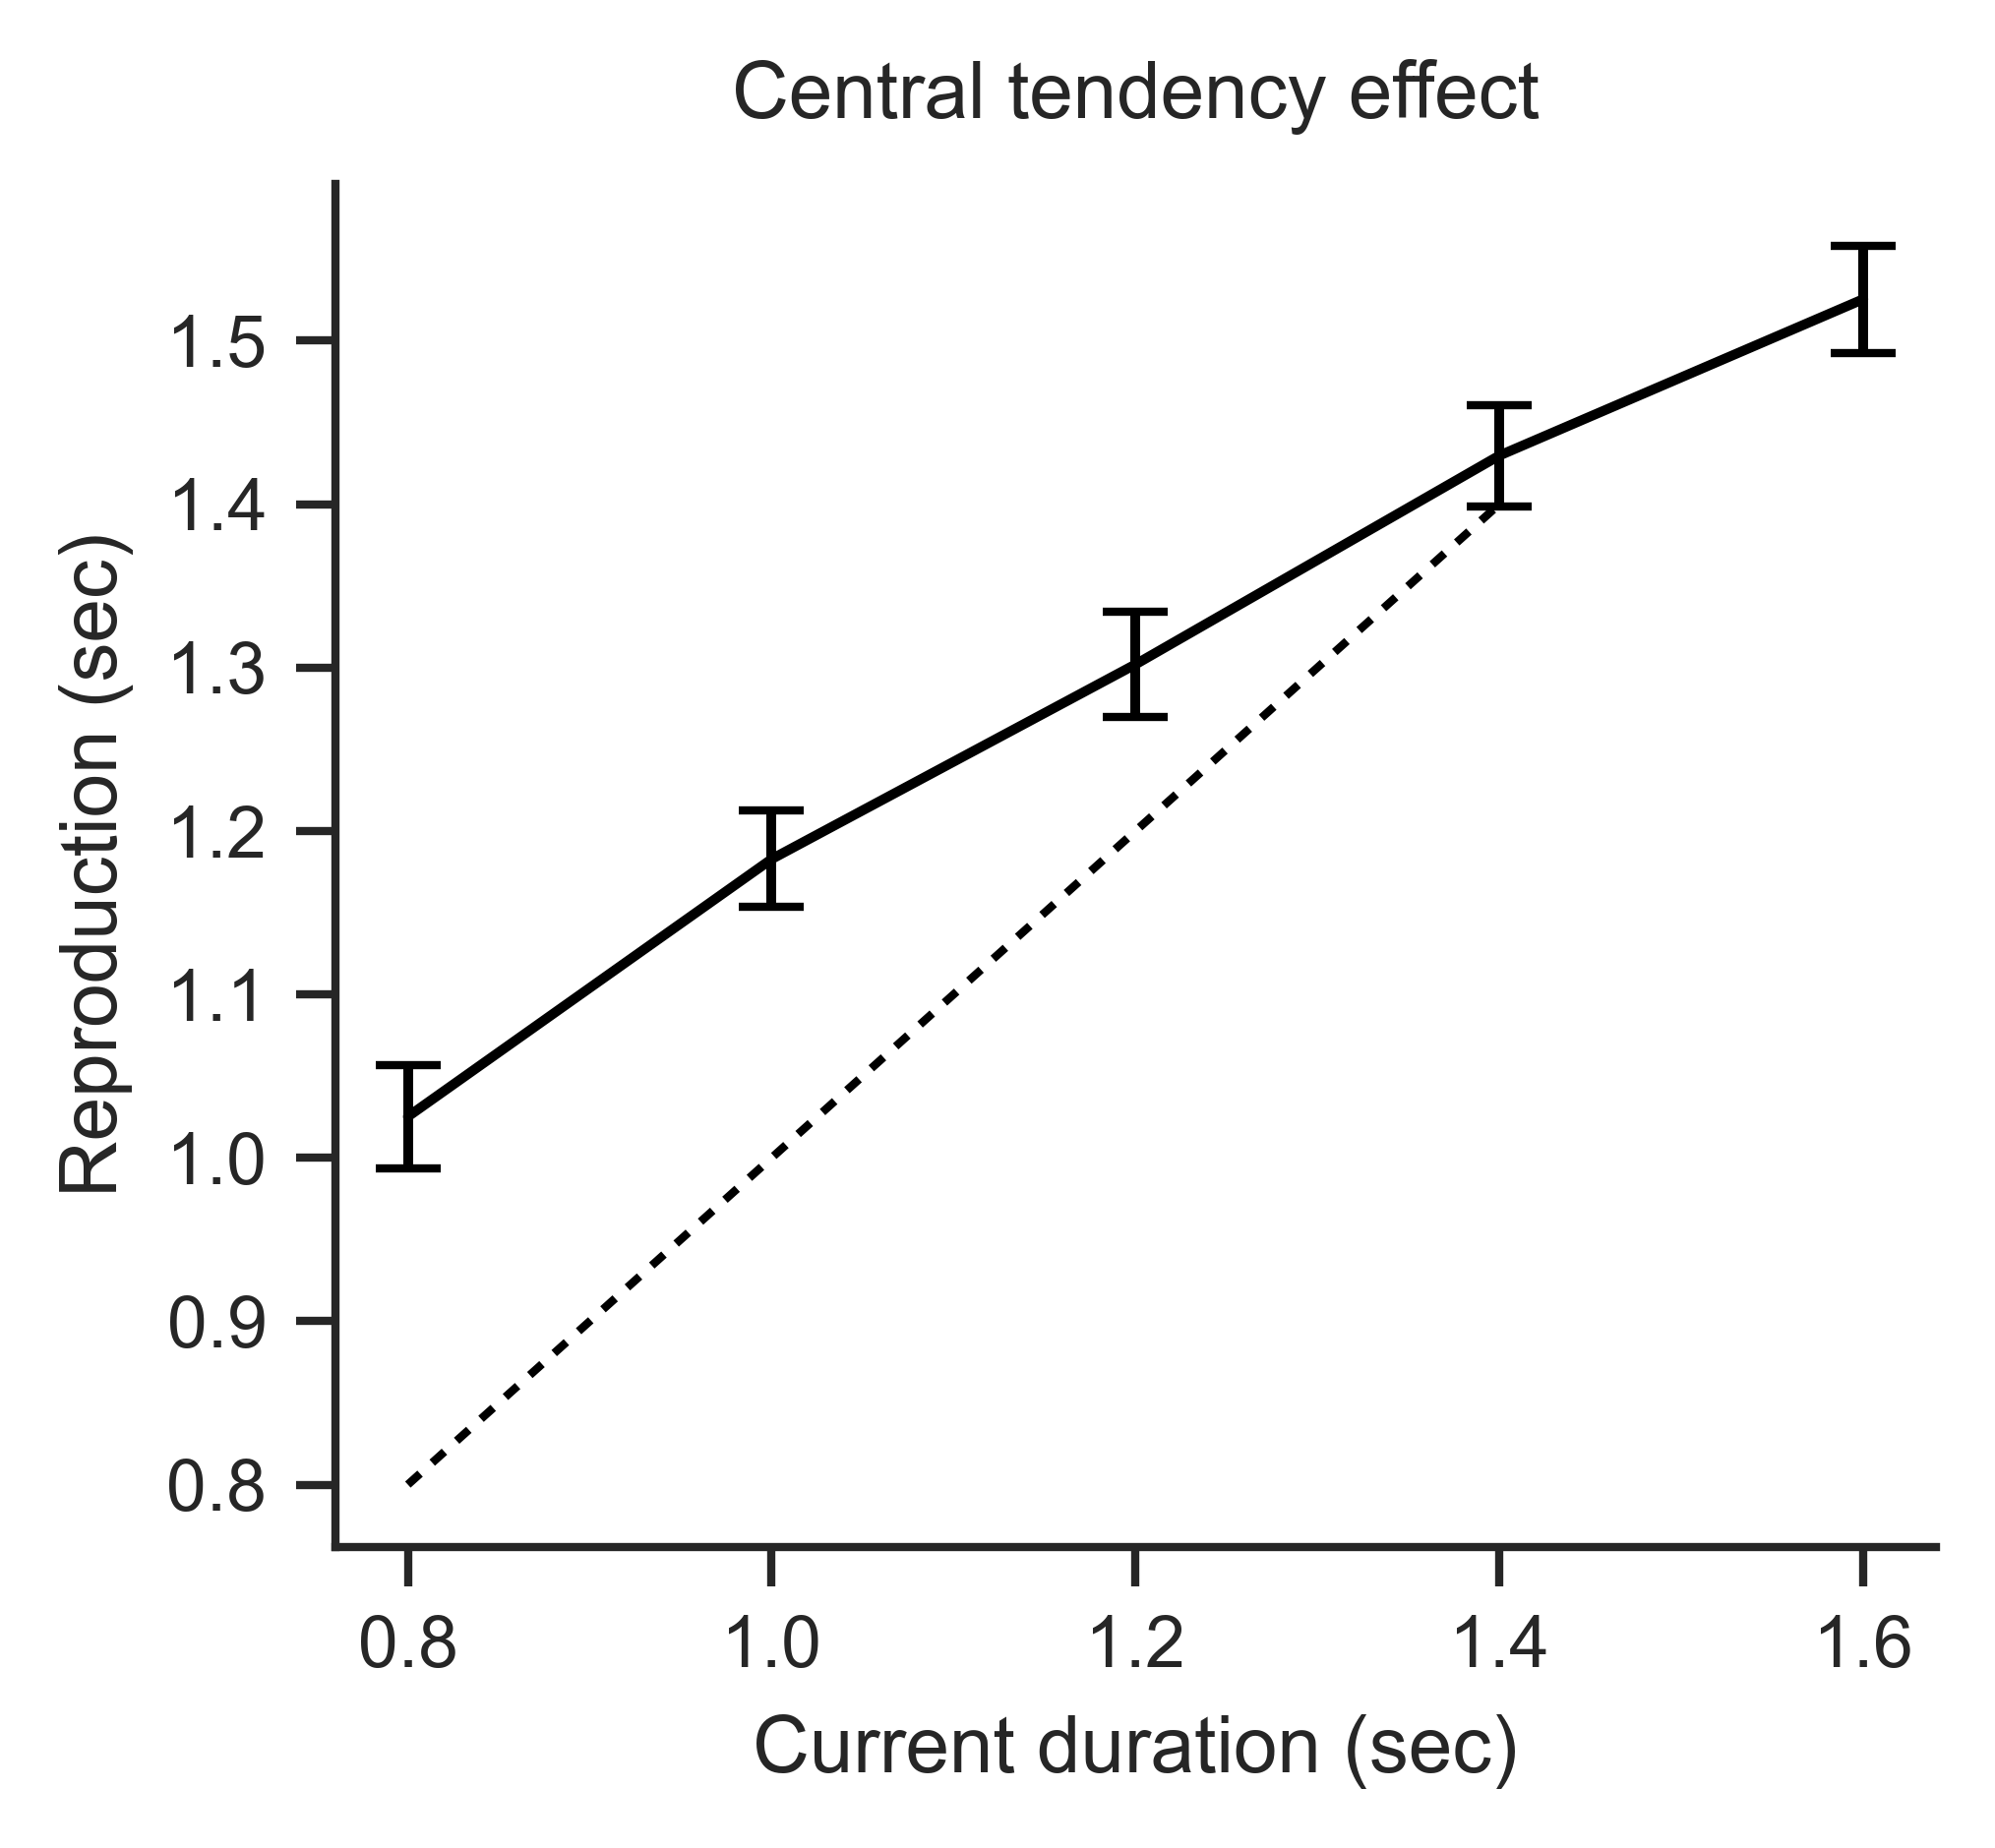

In [9]:
# # Central tendency based on Reproduction
mRprDurPar = df.groupby(['subID', 'curDur']).rpr.mean().reset_index()
mRprDurAll = mRprDurPar.groupby('curDur').\
     agg({"rpr":["count","mean","sem"]}).reset_index()
mRprDurAll.columns = ['curDur', 'count', 'mRpr','seRpr']
 # plot central tendency
fig, ax = plt.subplots()
plt.errorbar(x='curDur', y='mRpr', yerr='seRpr', data=mRprDurAll, 
              color='black', capsize=4)
plt.plot([0.8, 1.4], [0.8, 1.4], 'k-', lw=1, dashes=[2, 2])
plt.xticks(mRprDurAll.curDur)
plt.xlabel('Current duration (sec)')
plt.ylabel('Reproduction (sec)')
plt.title('Central tendency effect')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

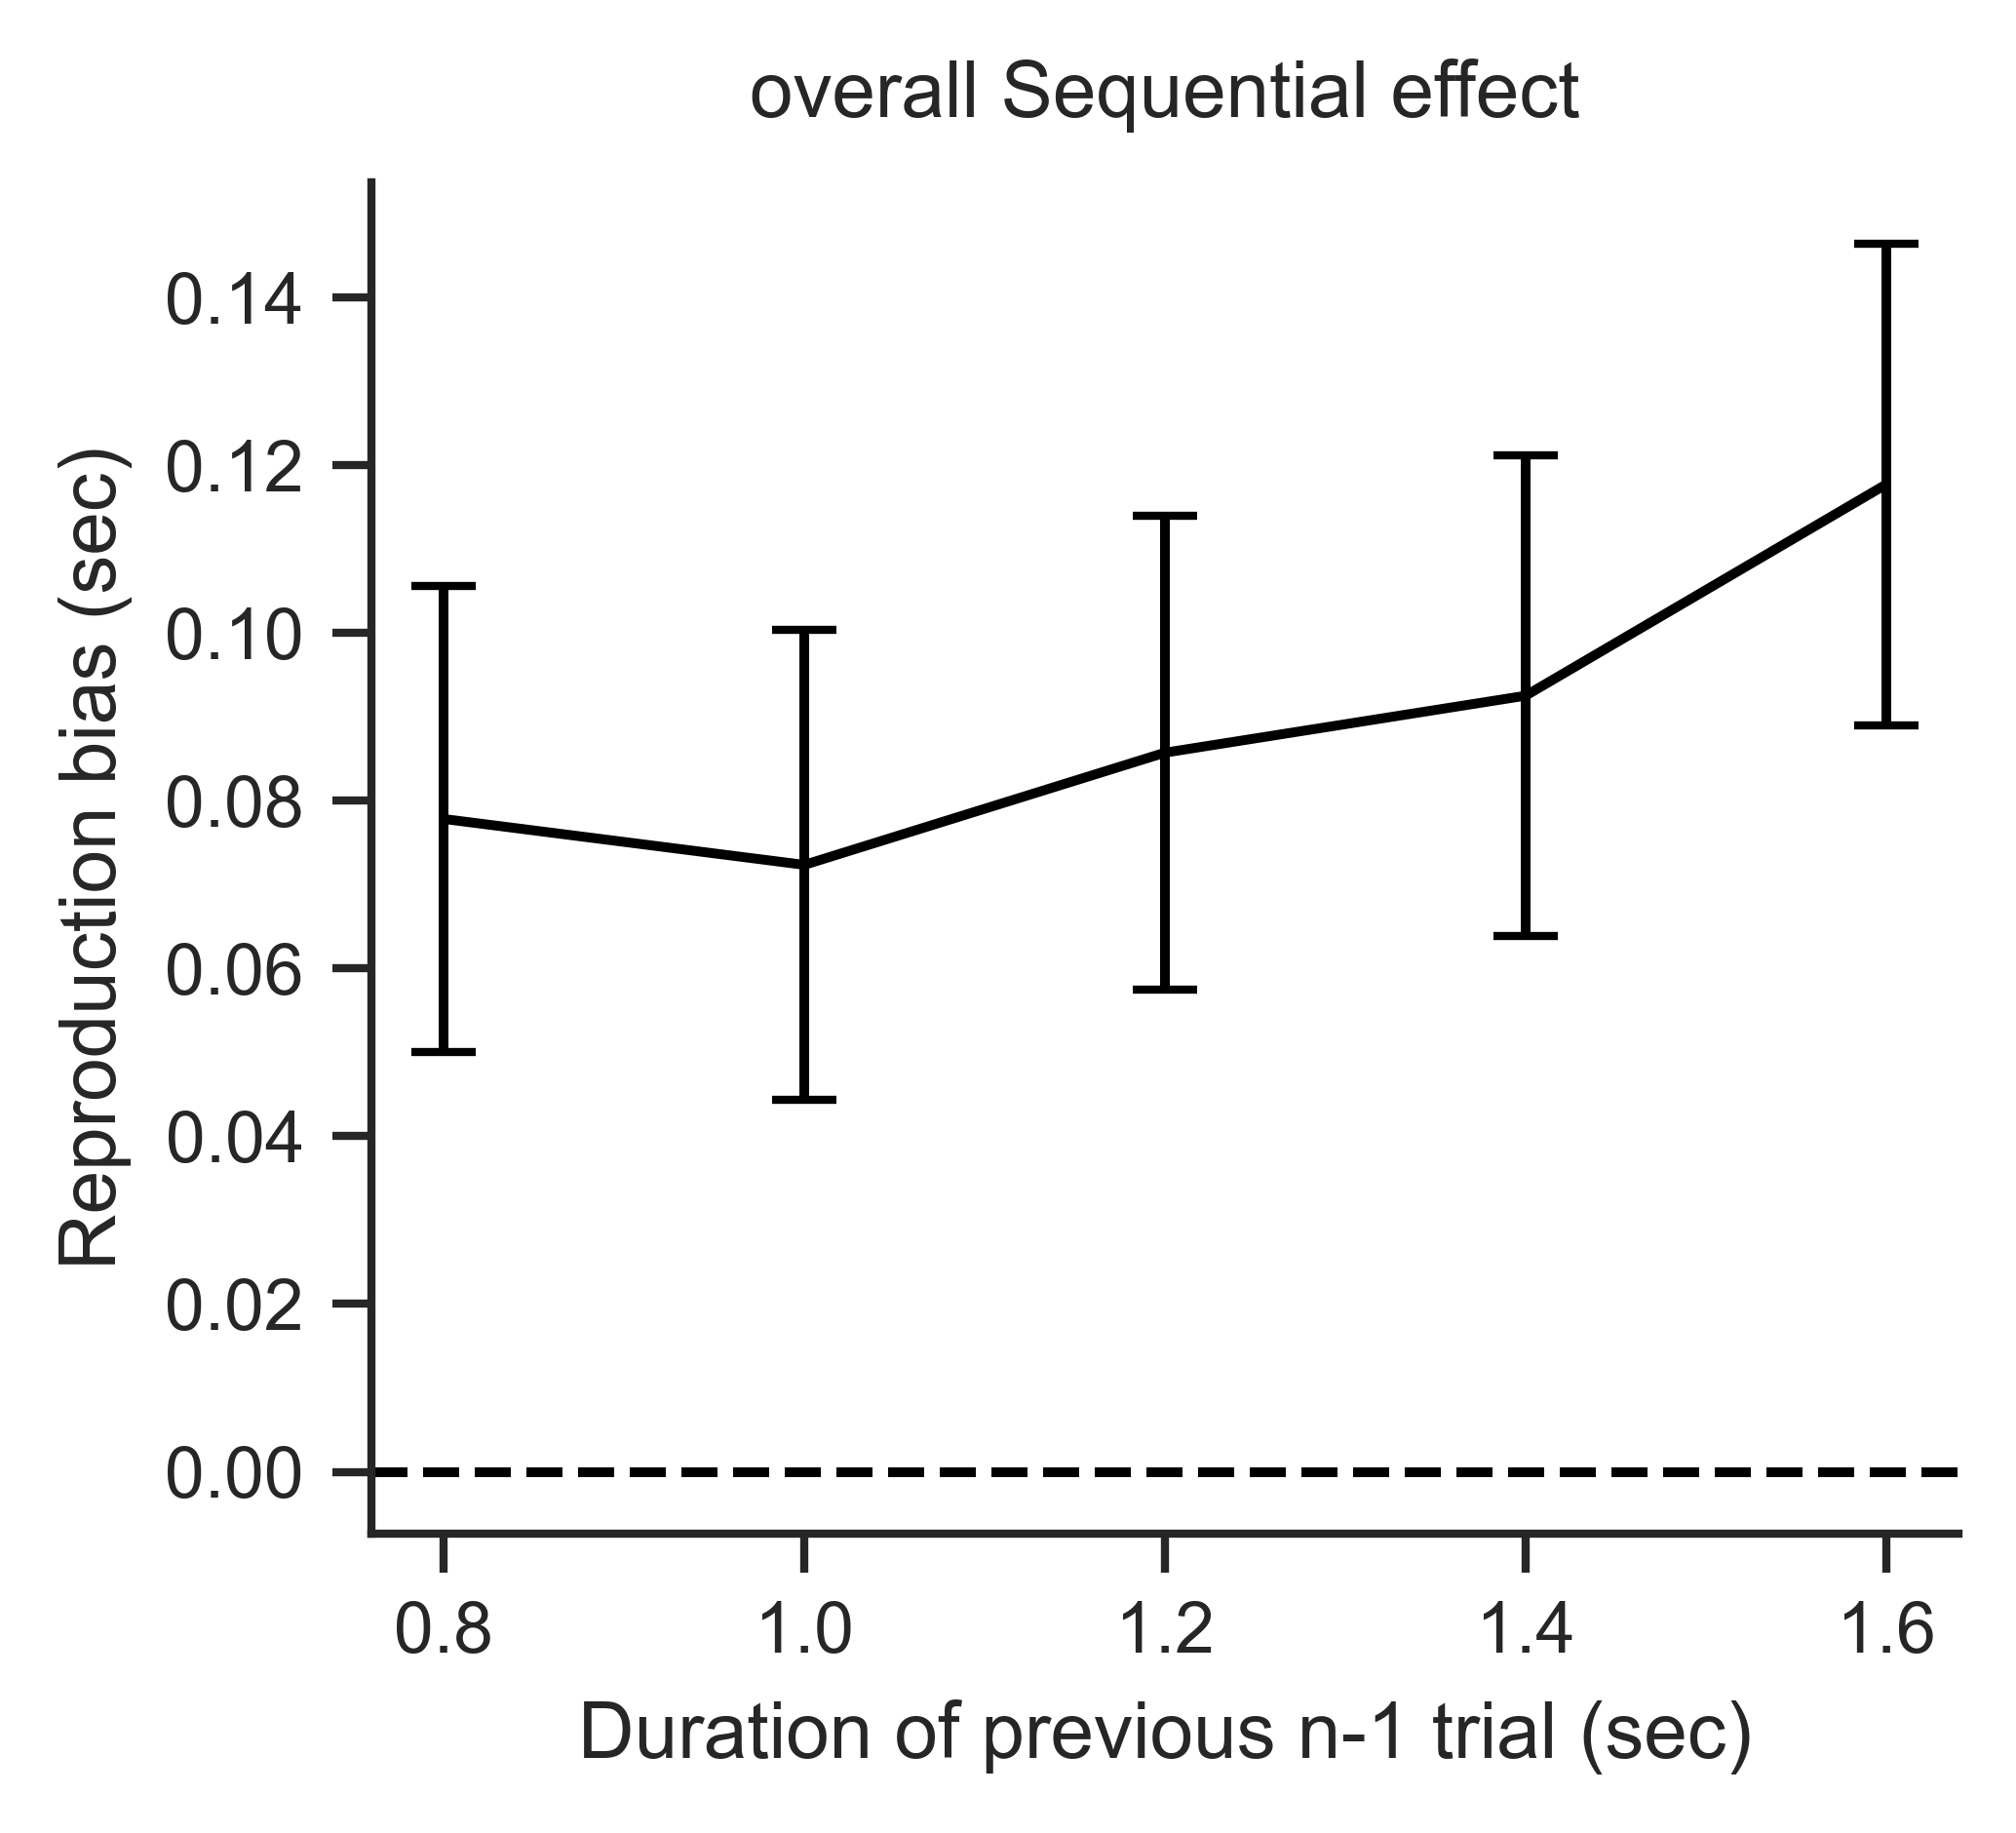

In [10]:
# overall Sequential effect (based on Reproduction Bias)
mBiasPreDurPar = df.groupby(['subID','preDur1back']).curBias.mean().reset_index()
mBiasPreDurAll = mBiasPreDurPar.groupby('preDur1back').\
    agg({"curBias":["count","mean","sem"]}).reset_index()
mBiasPreDurAll.columns = ['preDur1back', 'count', 'mBias','seBias']
# plot sequential effect
fig, ax = plt.subplots()
plt.errorbar(x='preDur1back', y='mBias', yerr='seBias', data=mBiasPreDurAll, 
             color='black', capsize=4)
plt.axhline(y=0, color='black', linestyle='--')
plt.xticks(mBiasPreDurAll.preDur1back)
plt.xlabel('Duration of previous n-1 trial (sec)')
plt.ylabel('Reproduction bias (sec)')
plt.title('overall Sequential effect')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

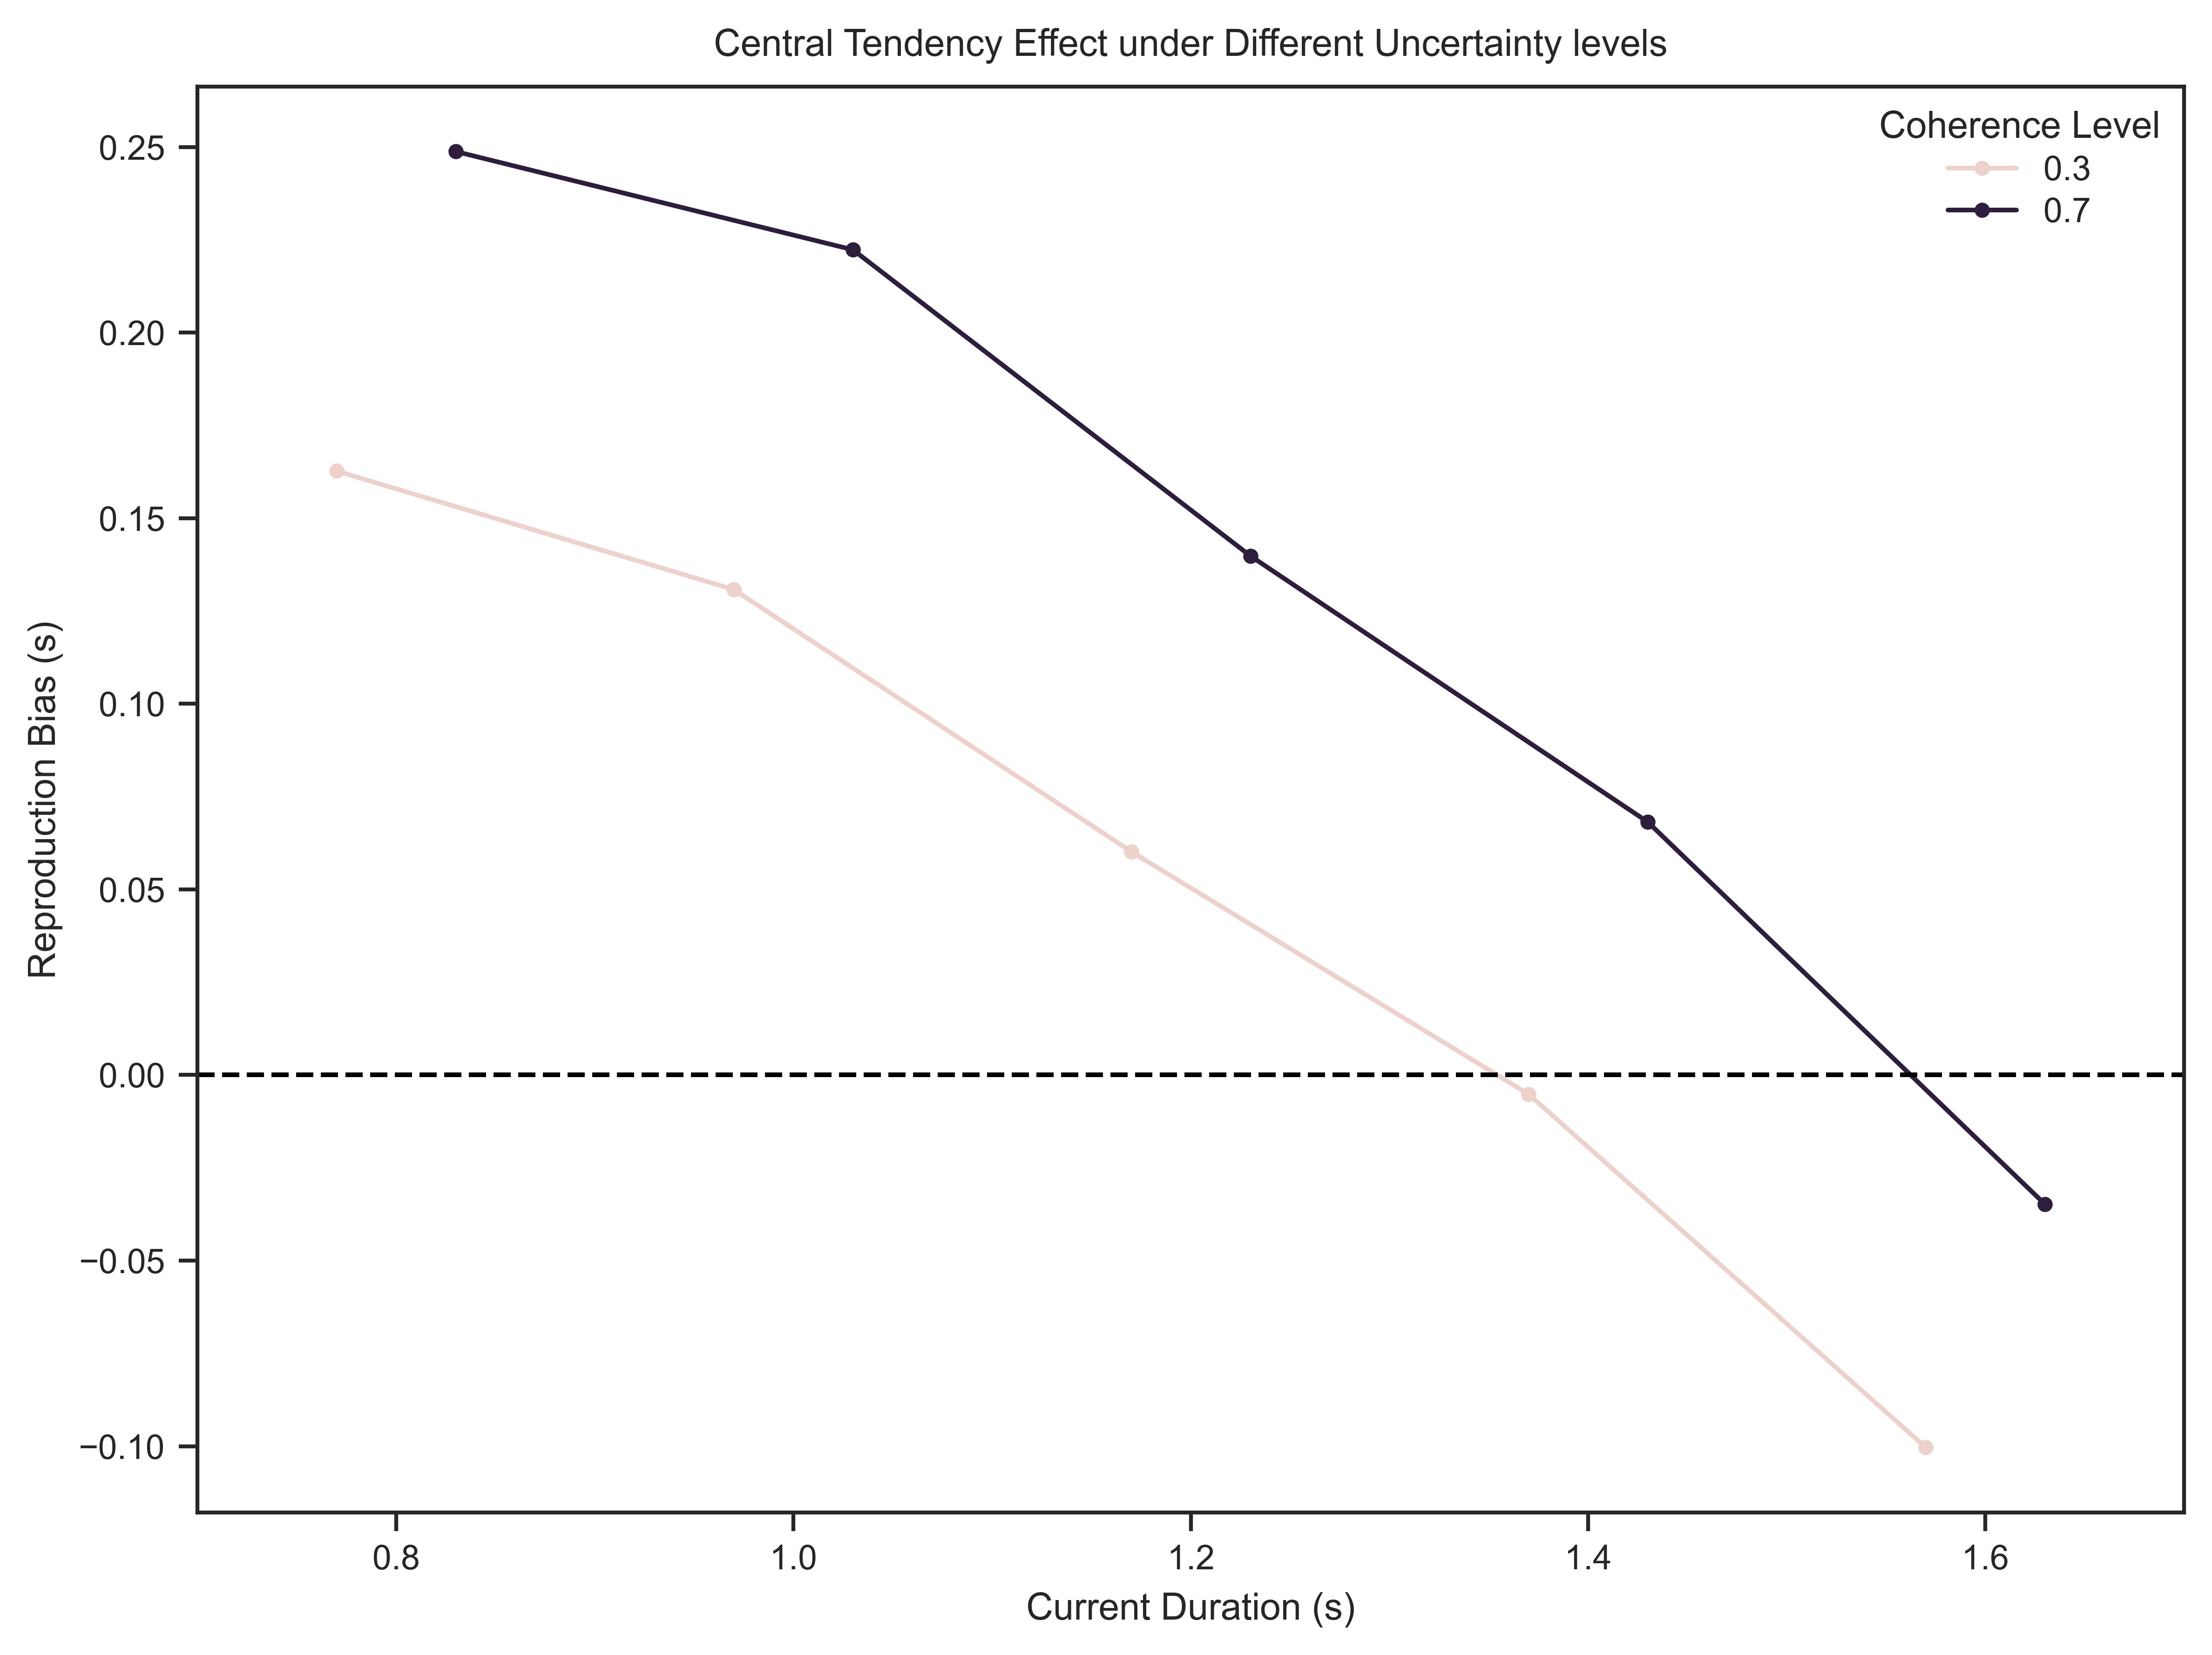

In [11]:
# Group by Uncertainty level
bias_grouped = df.groupby(['curCoherence', 'curDur'])['curBias'] \
    .agg(['count', 'mean', 'sem']).reset_index()
bias_grouped.columns = ['curCoherence', 'curDur', 'count', 'mBias', 'seBias']
# plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=bias_grouped,
              x='curDur', y='mBias', hue='curCoherence',
              dodge=0.3, capsize=0.1, linewidth=1.2)
plt.axhline(0, color='black', linestyle='--')
plt.title("Central Tendency Effect under Different Uncertainty levels")
plt.xlabel("Current Duration (s)")
plt.ylabel("Reproduction Bias (s)")
plt.legend(title="Coherence Level")
plt.tight_layout()
plt.show()

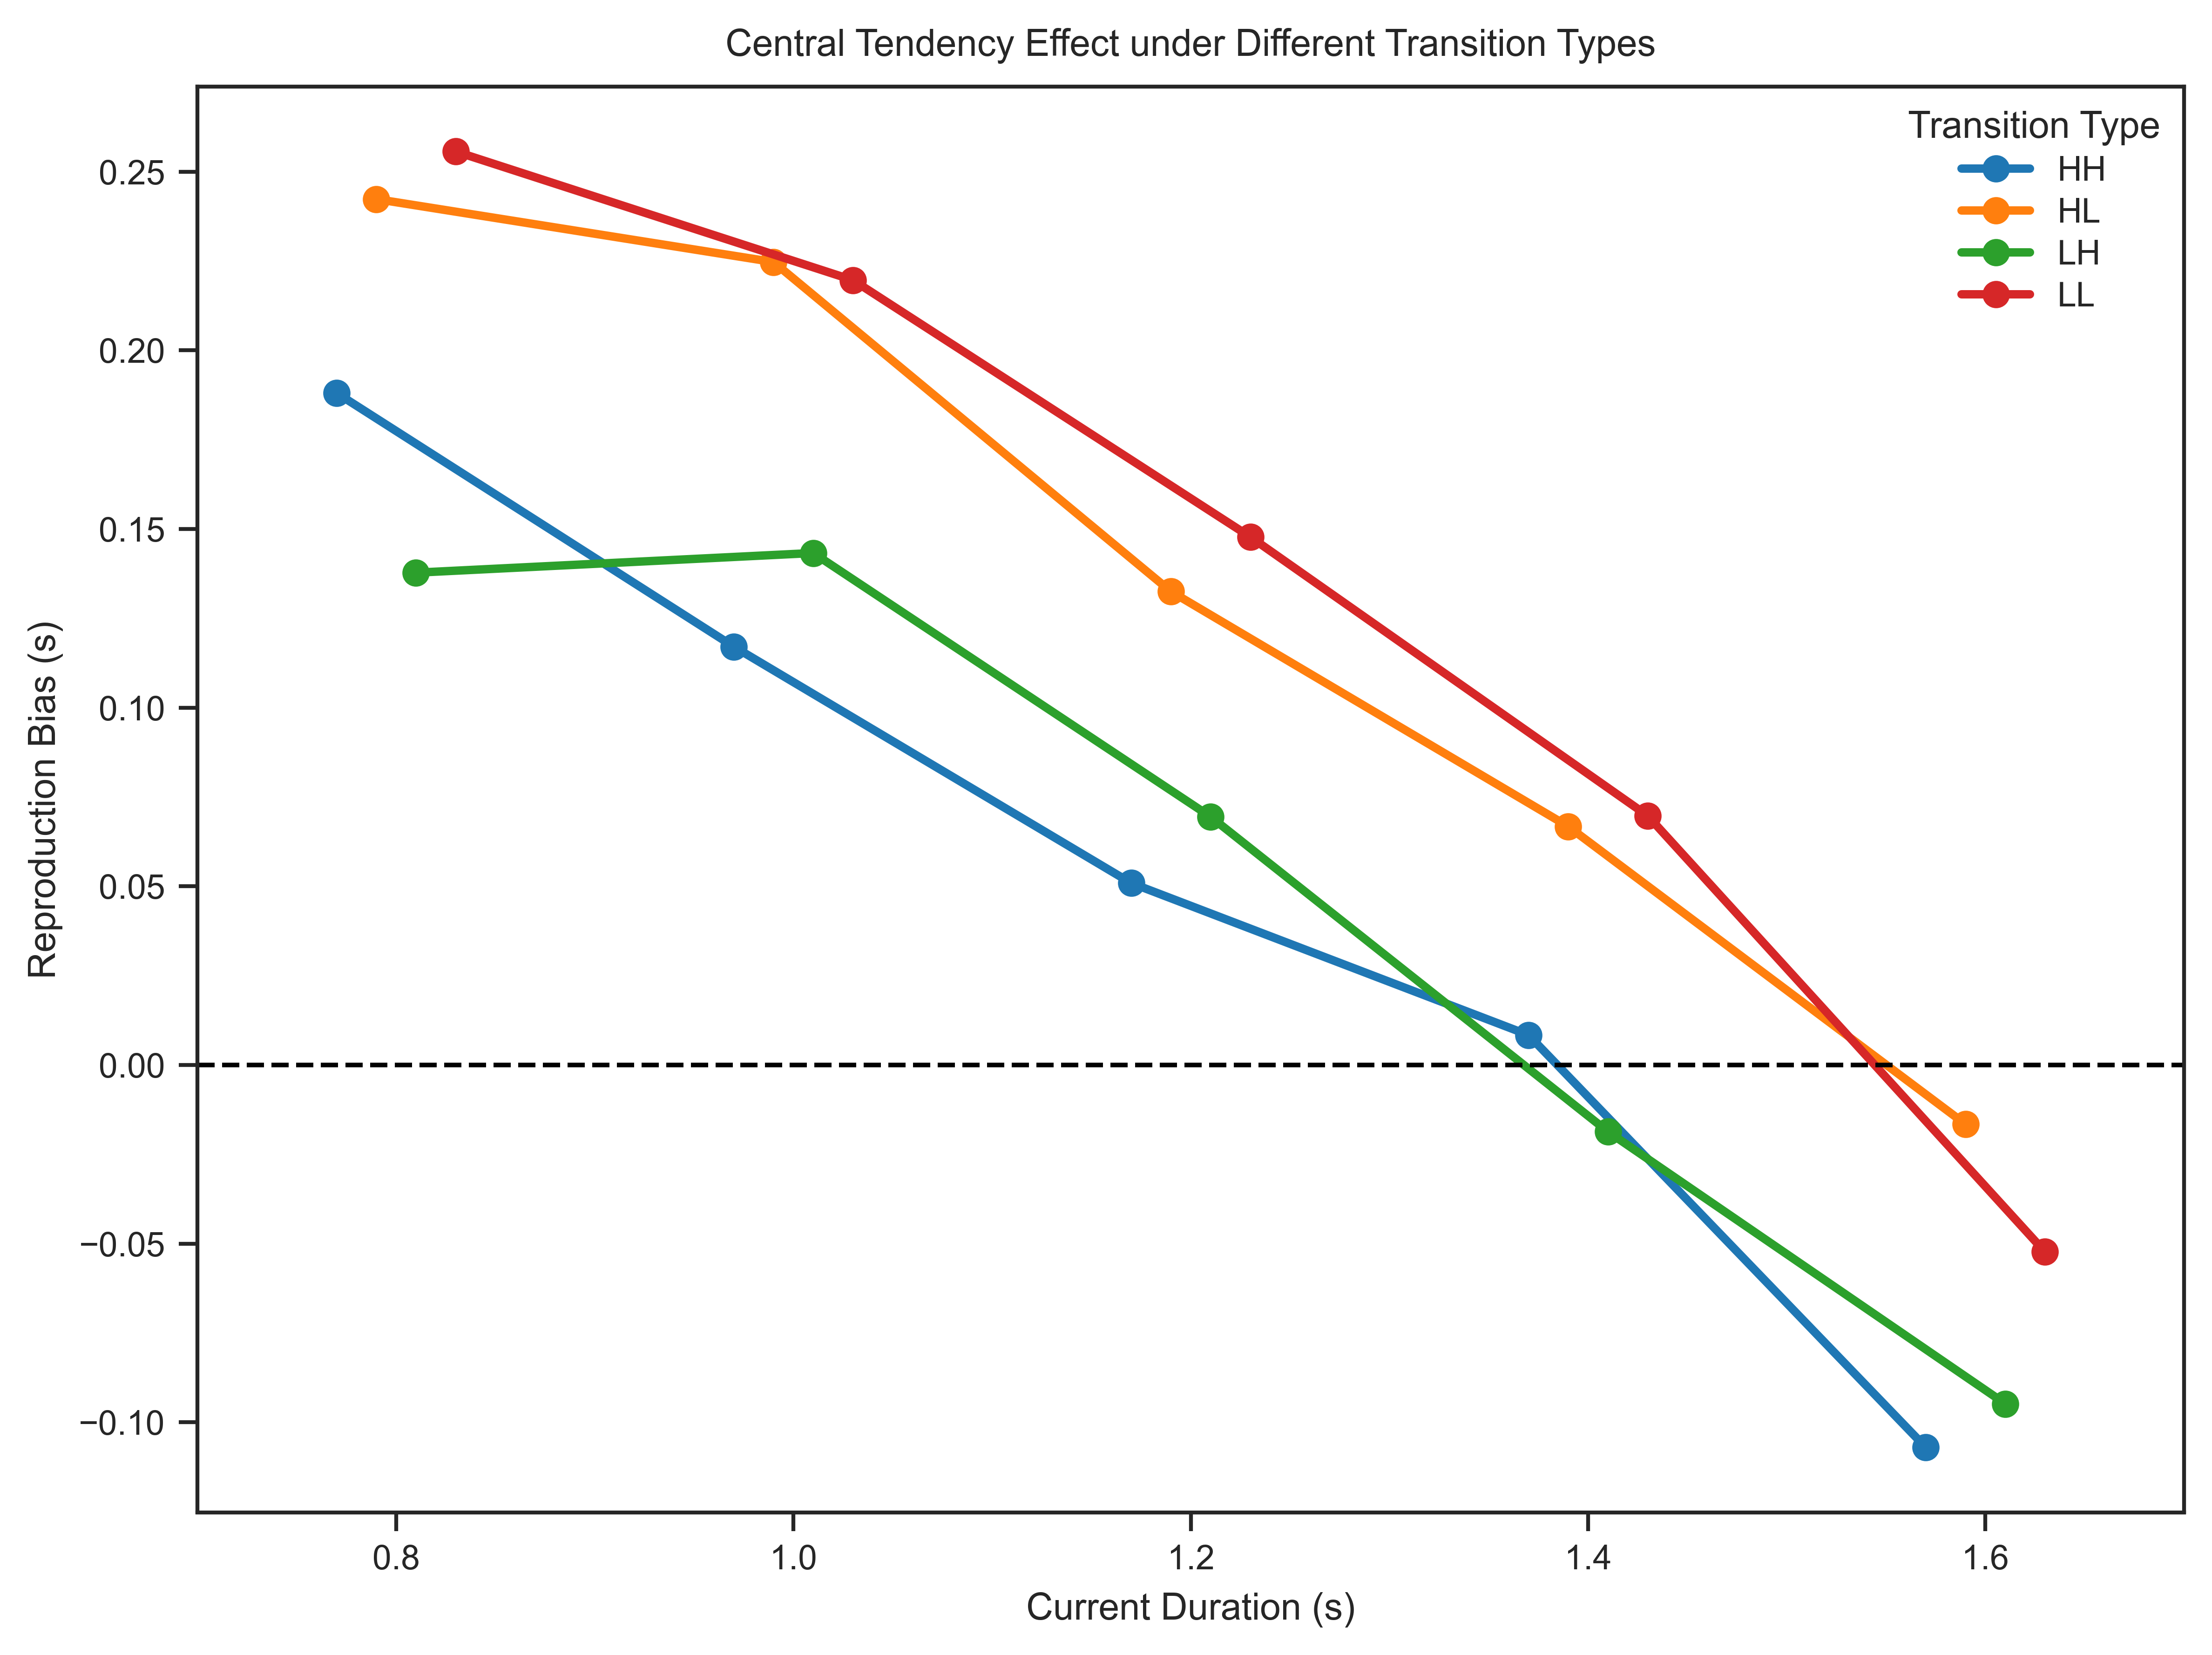

In [12]:
# Group by TransitionType & curDur 
bias_grouped = df.groupby(['TransitionType', 'curDur'])['curBias'] \
    .agg(['count', 'mean', 'sem']).reset_index()
bias_grouped.columns = ['TransitionType', 'curDur', 'count', 'mBias', 'seBias']
# plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=bias_grouped,
              x='curDur', y='mBias', hue='TransitionType',
              dodge=0.3, capsize=0.1, errwidth=1.2)
plt.axhline(0, color='black', linestyle='--')
plt.title("Central Tendency Effect under Different Transition Types")
plt.xlabel("Current Duration (s)")
plt.ylabel("Reproduction Bias (s)")
plt.legend(title="Transition Type")
plt.tight_layout()
plt.show()

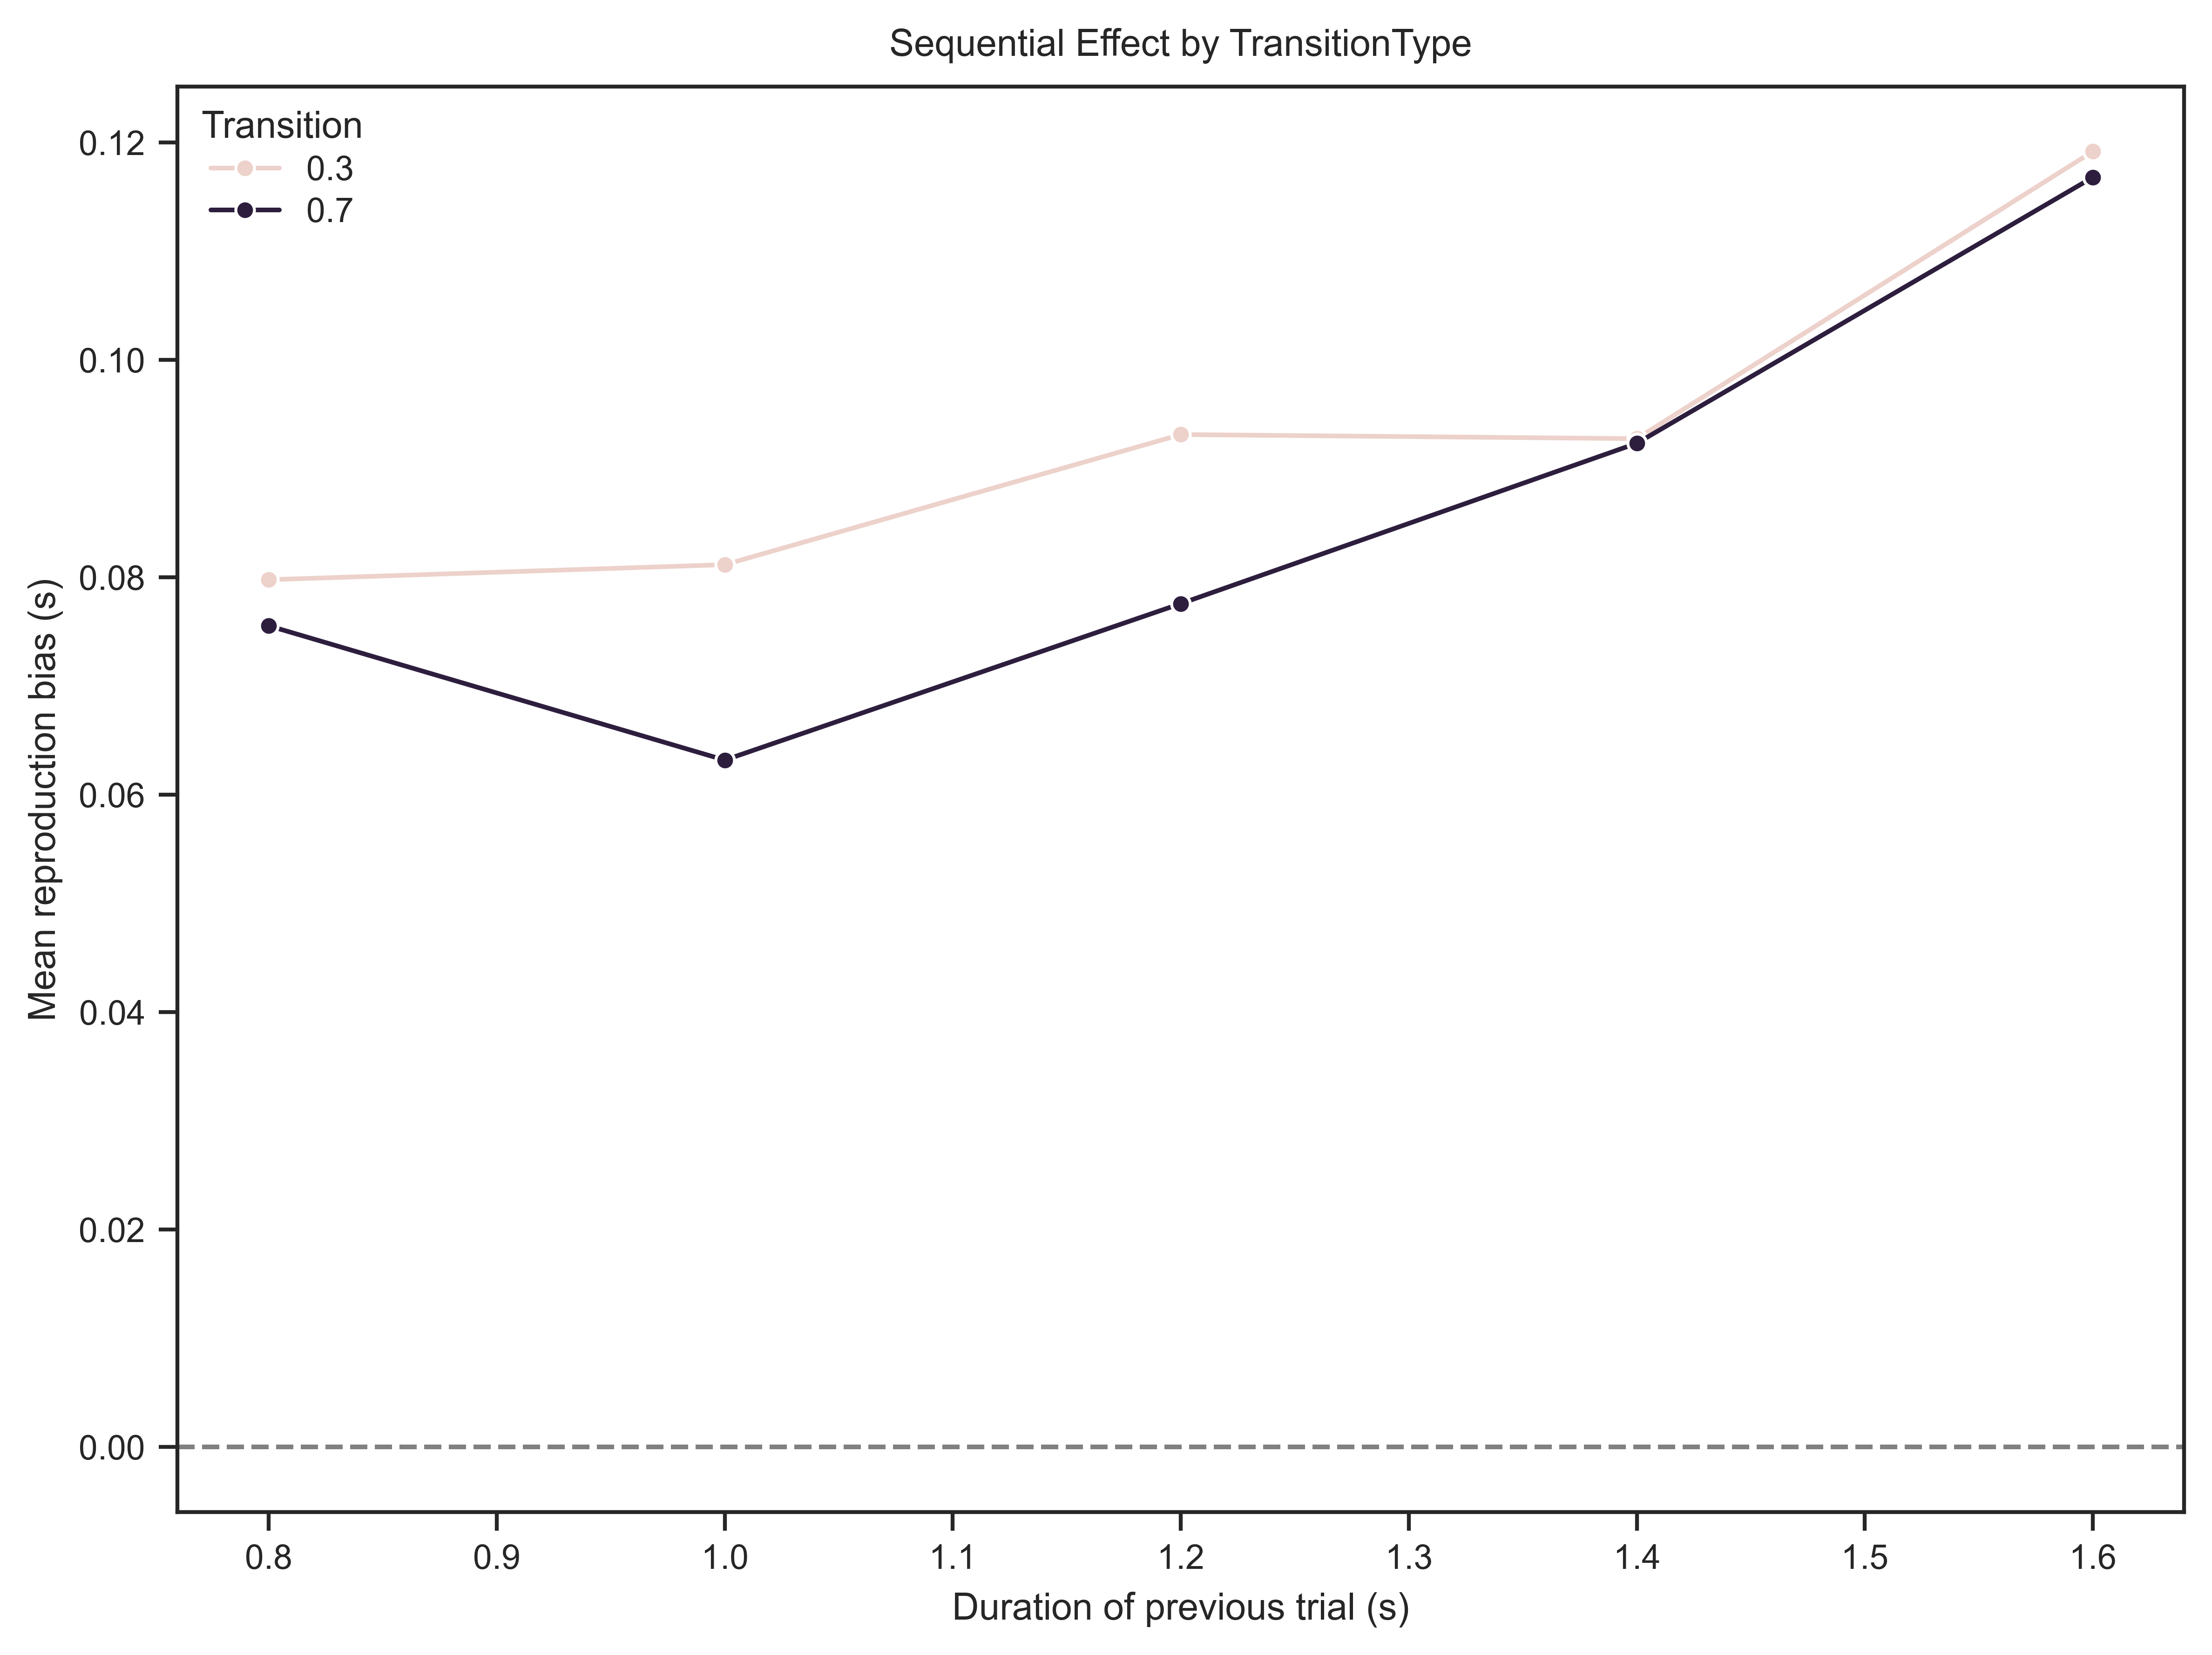

In [13]:
mBias_byTrans = df.groupby(['subID', 'preCoherence1back', 'preDur1back'])['curBias'].mean().reset_index()
mBias_byTrans_all = mBias_byTrans.groupby(['preCoherence1back', 'preDur1back']).agg(
    count=('curBias', 'count'),
    mBias=('curBias', 'mean'),
    seBias=('curBias', 'sem')
).reset_index()
plt.figure(figsize=(8, 6))
sns.lineplot(
    data=mBias_byTrans_all,
    x='preDur1back',
    y='mBias',
    hue='preCoherence1back',
    marker='o', err_style="bars", err_kws={'capsize': 4}
)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Duration of previous trial (s)')
plt.ylabel('Mean reproduction bias (s)')
plt.title('Sequential Effect by TransitionType')
plt.legend(title='Transition')
plt.tight_layout()
plt.show()


---
## Descriptive Statistics


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import sem
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Load Data

In [15]:
df = pd.read_pickle('E1.pkl')
df = df[df['is_outlier'] == False].copy()
print(f'Loaded {len(df)} trials, {df["subID"].nunique()} subjects')
print(f'Conditions: {df["TransitionType"].unique()}')

Loaded 4670 trials, 22 subjects
Conditions: <ArrowStringArray>
['LH', 'HH', 'HL', 'LL']
Length: 4, dtype: string


## Basic Statistics

In [16]:
# Trial counts per subject
trial_counts = df.groupby('subID').size()
print('Trials per subject:')
print(f'  Mean: {trial_counts.mean():.1f}, SD: {trial_counts.std():.1f}')
print(f'  Range: {trial_counts.min()} - {trial_counts.max()}')

# Trials per condition
print('\nTrials per TransitionType:')
print(df.groupby('TransitionType').size())

# Duration distribution
print('\nCurrent Duration levels:', sorted(df['curDur'].unique()))
print('Previous Duration levels:', sorted(df['preDur1back'].unique()))

Trials per subject:
  Mean: 212.3, SD: 12.5
  Range: 187 - 229

Trials per TransitionType:
TransitionType
HH    1133
HL    1206
LH    1201
LL    1130
dtype: int64

Current Duration levels: [np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6)]
Previous Duration levels: [np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.4), np.float64(1.6)]


In [17]:
# Response statistics
print('Reproduction (rpr):')
print(f'  Mean: {df["rpr"].mean():.3f}, SD: {df["rpr"].std():.3f}')

print('\nBias (curBias):')
print(f'  Mean: {df["curBias"].mean():.3f}, SD: {df["curBias"].std():.3f}')

# By condition
print('\nMean Bias by TransitionType:')
print(df.groupby('TransitionType')['curBias'].agg(['mean', 'std', 'sem']).round(3))

Reproduction (rpr):
  Mean: 1.295, SD: 0.304

Bias (curBias):
  Mean: 0.087, SD: 0.262

Mean Bias by TransitionType:
                 mean    std    sem
TransitionType                     
HH              0.052  0.263  0.008
HL              0.128  0.245  0.007
LH              0.044  0.276  0.008
LL              0.123  0.251  0.007


## Exploratory Figures

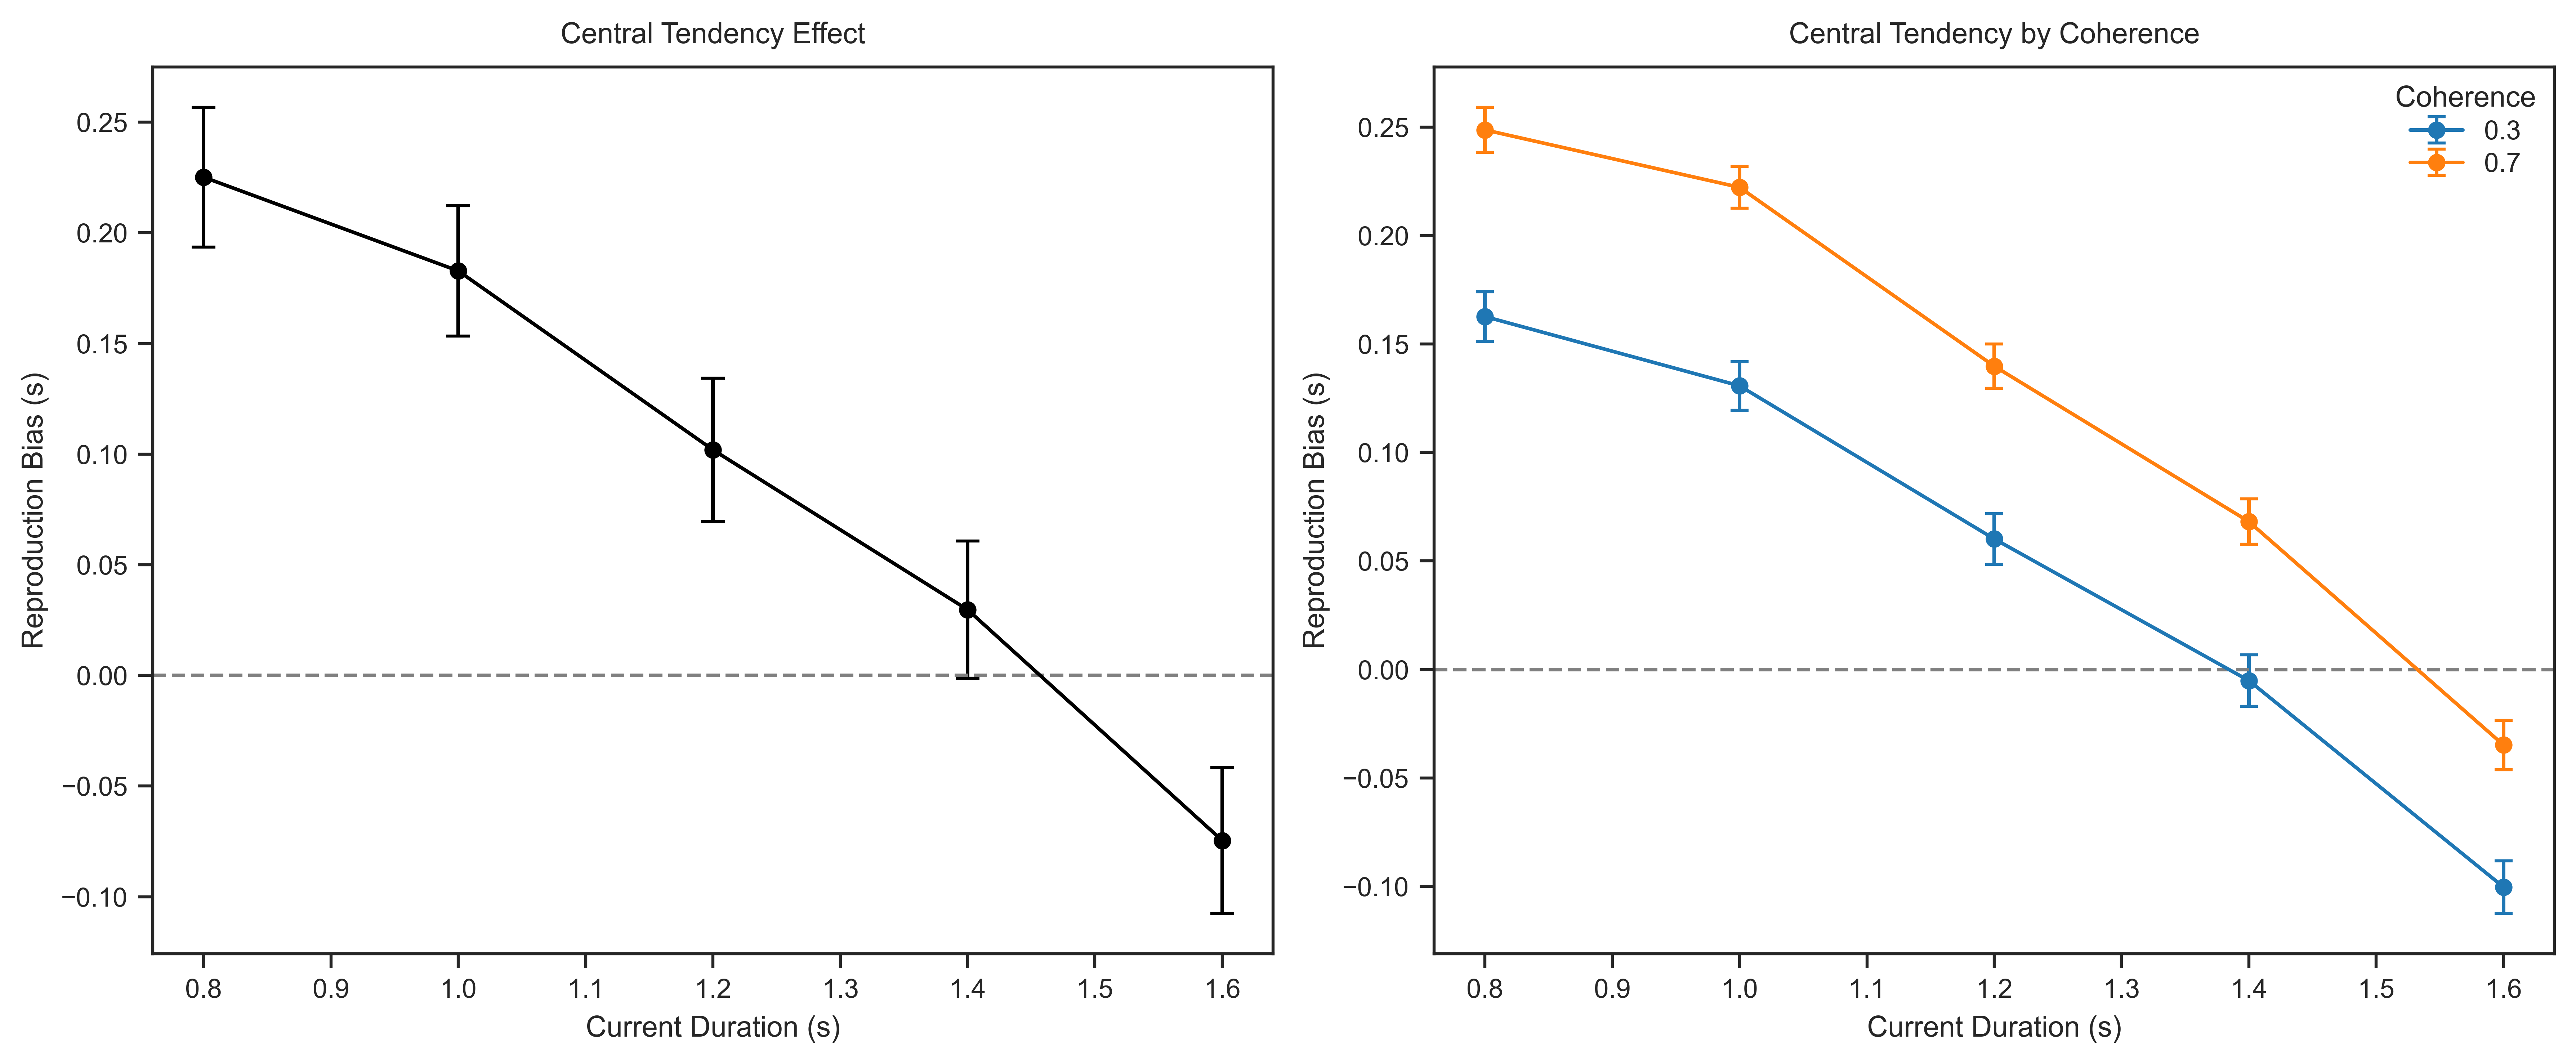

In [18]:
# Central Tendency: Bias vs Current Duration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Overall
ct_data = df.groupby(['subID', 'curDur'])['curBias'].mean().reset_index()
ct_summary = ct_data.groupby('curDur')['curBias'].agg(['mean', 'sem']).reset_index()
axes[0].errorbar(ct_summary['curDur'], ct_summary['mean'], yerr=ct_summary['sem'], 
                 color='black', capsize=4, marker='o')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Current Duration (s)')
axes[0].set_ylabel('Reproduction Bias (s)')
axes[0].set_title('Central Tendency Effect')

# Panel B: By Coherence
ct_coh = df.groupby(['curCoherence', 'curDur'])['curBias'].agg(['mean', 'sem']).reset_index()
for coh in ct_coh['curCoherence'].unique():
    sub = ct_coh[ct_coh['curCoherence'] == coh]
    axes[1].errorbar(sub['curDur'], sub['mean'], yerr=sub['sem'], 
                     label=f'{coh}', capsize=3, marker='o')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Current Duration (s)')
axes[1].set_ylabel('Reproduction Bias (s)')
axes[1].set_title('Central Tendency by Coherence')
axes[1].legend(title='Coherence')

plt.tight_layout()
plt.show()

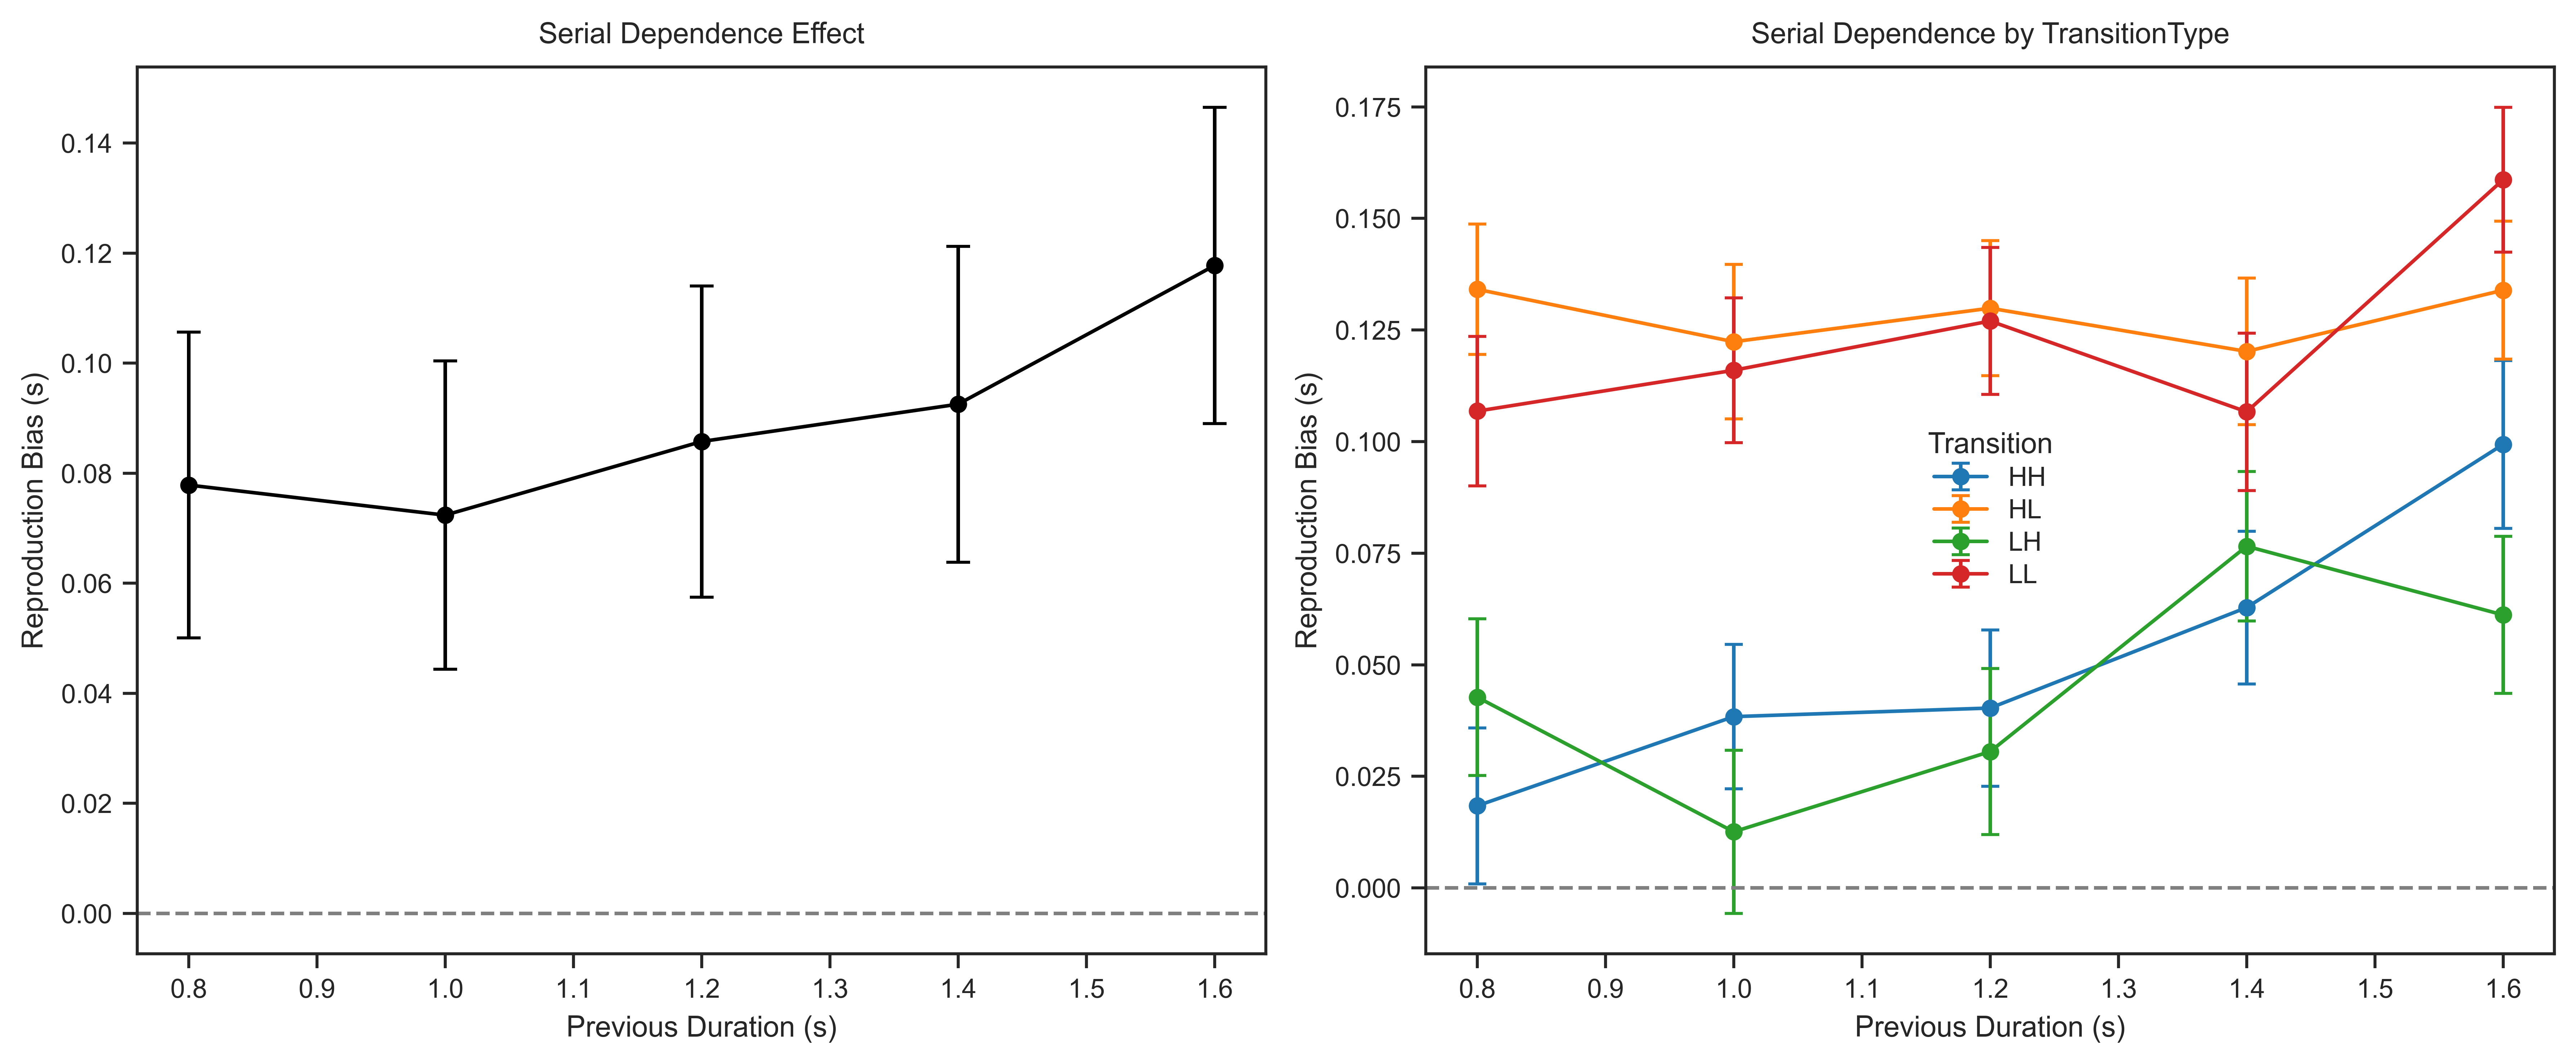

In [ ]:
# Serial Dependence: Bias vs Previous Duration
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Overall
sd_data = df.groupby(['subID', 'preDur1back'])['curBias'].mean().reset_index()
sd_summary = sd_data.groupby('preDur1back')['curBias'].agg(['mean', 'sem']).reset_index()
axes[0].errorbar(sd_summary['preDur1back'], sd_summary['mean'], yerr=sd_summary['sem'],
                 color='black', capsize=4, marker='o')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_xlabel('Previous Duration (s)')
axes[0].set_ylabel('Reproduction Bias (s)')
axes[0].set_title('Serial Dependence Effect')

# Panel B: By TransitionType
sd_trans = df.groupby(['TransitionType', 'preDur1back'])['curBias'].agg(['mean', 'sem']).reset_index()
for trans in ['HH', 'HL', 'LH', 'LL']:
    sub = sd_trans[sd_trans['TransitionType'] == trans]
    axes[1].errorbar(sub['preDur1back'], sub['mean'], yerr=sub['sem'],
                     label=trans, capsize=3, marker='o')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Previous Duration (s)')
axes[1].set_ylabel('Reproduction Bias (s)')
axes[1].set_title('Serial Dependence by TransitionType')
axes[1].legend(title='Transition')

plt.tight_layout()
plt.show()

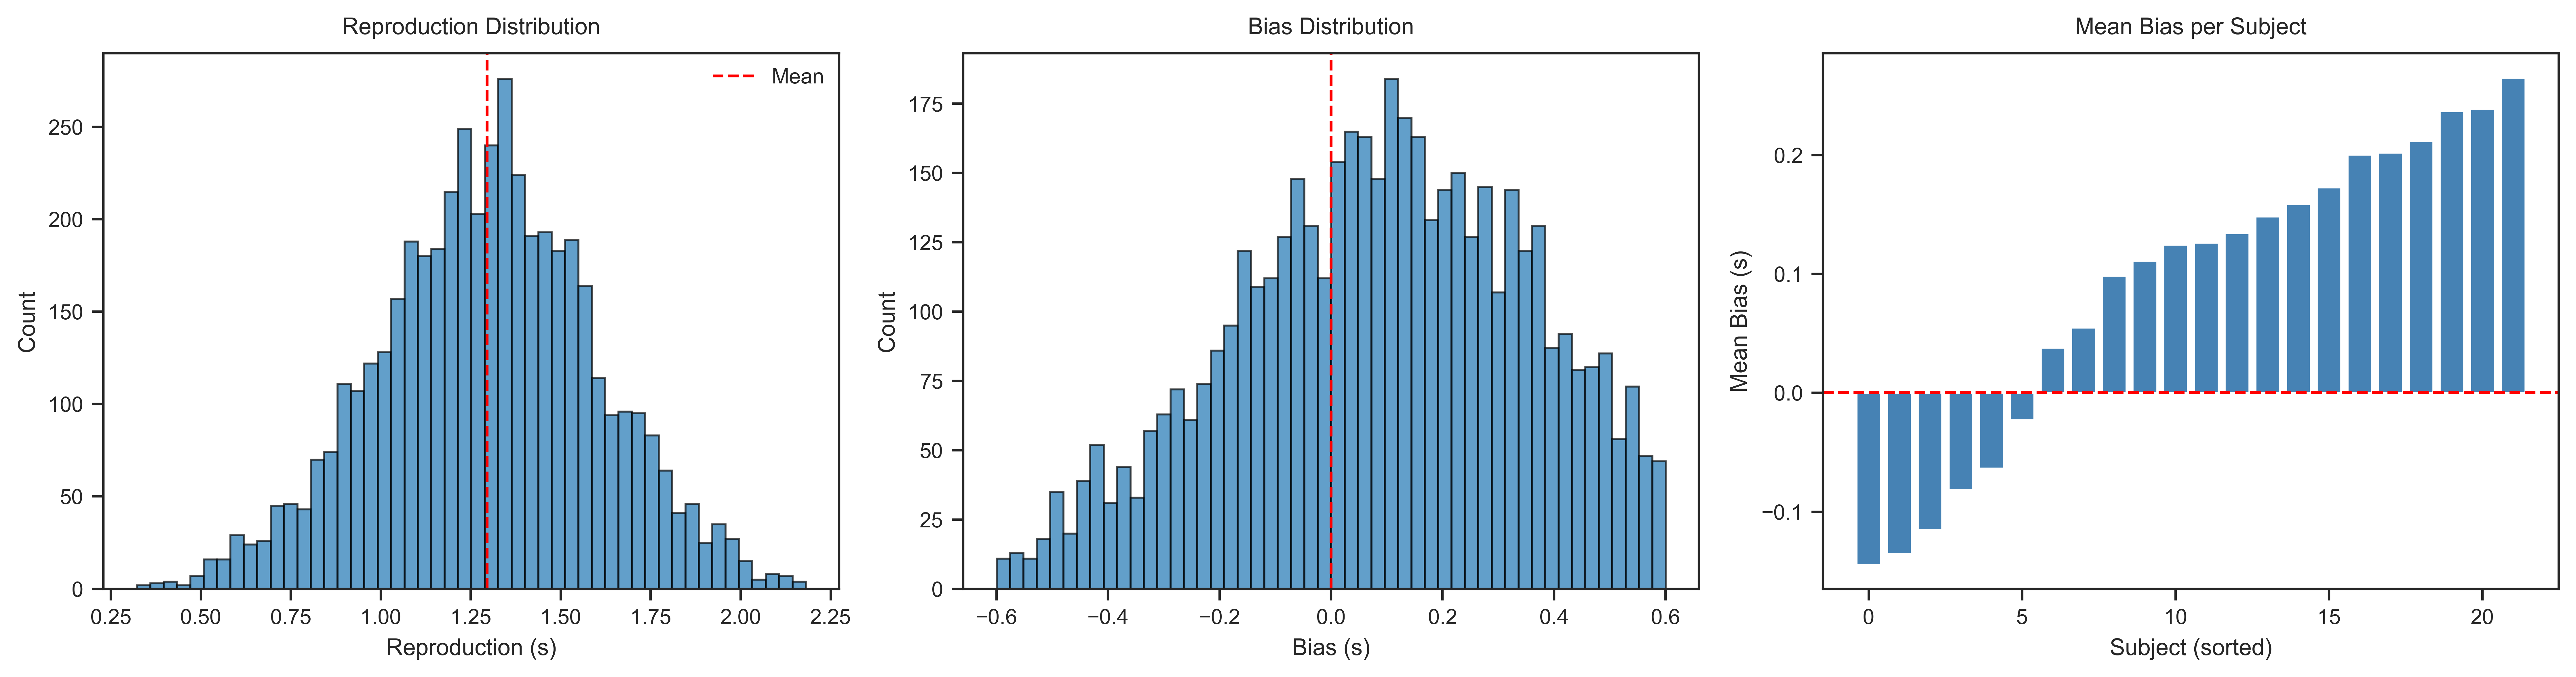

In [ ]:
# Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Reproduction distribution
axes[0].hist(df['rpr'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['rpr'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Reproduction (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Reproduction Distribution')
axes[0].legend()

# Bias distribution
axes[1].hist(df['curBias'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Bias (s)')
axes[1].set_ylabel('Count')
axes[1].set_title('Bias Distribution')

# Bias by subject
subject_bias = df.groupby('subID')['curBias'].mean().sort_values()
axes[2].bar(range(len(subject_bias)), subject_bias.values, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Subject (sorted)')
axes[2].set_ylabel('Mean Bias (s)')
axes[2].set_title('Mean Bias per Subject')

plt.tight_layout()
plt.show()

## Summary Statistics Table

In [ ]:
# Summary by TransitionType
summary = df.groupby('TransitionType').agg({
    'curBias': ['mean', 'std', 'sem'],
    'rpr': ['mean', 'std'],
    'subID': 'nunique'
}).round(3)
summary.columns = ['Bias_mean', 'Bias_std', 'Bias_sem', 'Rpr_mean', 'Rpr_std', 'N_subjects']
print('Summary by TransitionType:')
display(summary)

Summary by TransitionType:


,Bias_mean,Bias_std,Bias_sem,Rpr_mean,Rpr_std,N_subjects
TransitionType,,,,,,
HH,0.052,0.263,0.008,1.253,0.304,22
HL,0.128,0.245,0.007,1.335,0.291,22
LH,0.044,0.276,0.008,1.255,0.324,22
LL,0.123,0.251,0.007,1.337,0.285,22


---
## Decisional Carryover Effect (DCEI) by Current Coherence

Analyze how the previous trial's decision (Long/Short) affects the current trial's reproduction bias, grouped by current trial's coherence level (High vs Low).

**DCEI = curBias(preResp=Long) - curBias(preResp=Short)**

In [ ]:
def calc_dcei(df, group_col=None):
    """
    Calculate Decisional Carryover Effect Index (DCEI)
    
    Args:
        df: DataFrame containing subID, rpr, curBias, is_outlier columns
        group_col: Optional column to group by (e.g., 'curCoherence')
    
    Returns:
        df_result: DataFrame with Long, Short, DCEI for each subject (and group if specified)
    """
    df = df[df['is_outlier'] == False].copy()
    
    # Calculate response type: based on within-subject mean response time
    df['mean_rpr'] = df.groupby('subID')['rpr'].transform('mean')
    df['resp_type'] = np.where(df['rpr'] > df['mean_rpr'], 'Long', 'Short')
    
    # Previous trial's response type
    df['preResp'] = df.groupby('subID')['resp_type'].shift(1)
    
    df_clean = df.dropna(subset=['preResp', 'curBias'])
    
    if group_col is None:
        # Overall DCEI
        df_effect = df_clean.groupby(['subID', 'preResp'])['curBias'].mean().reset_index()
        df_pivot = df_effect.pivot(index='subID', columns='preResp', values='curBias').dropna()
        df_pivot['DCEI'] = df_pivot['Long'] - df_pivot['Short']
        return df_pivot
    else:
        # DCEI by group
        df_effect = df_clean.groupby(['subID', group_col, 'preResp'])['curBias'].mean().reset_index()
        df_pivot = df_effect.pivot(index=['subID', group_col], columns='preResp', values='curBias').reset_index()
        df_pivot = df_pivot.dropna()
        df_pivot['DCEI'] = df_pivot['Long'] - df_pivot['Short']
        return df_pivot

In [ ]:
# Load original data and calculate DCEI
df_exp2 = pd.read_pickle('E1.pkl')

# Overall DCEI
dcei_overall = calc_dcei(df_exp2, group_col=None)
n = len(dcei_overall)
mean_dcei = dcei_overall['DCEI'].mean()
sem_dcei = dcei_overall['DCEI'].sem()
std_dcei = dcei_overall['DCEI'].std(ddof=1)
t, p = ttest_1samp(dcei_overall['DCEI'], popmean=0)
d = mean_dcei / std_dcei

print("=" * 50)
print("Overall DCEI (Exp 2)")
print("=" * 50)
print(f"  n = {n}")
print(f"  Mean DCEI = {mean_dcei:.4f}")
print(f"  SEM = {sem_dcei:.4f}")
print(f"  One-sample t-test vs 0: t({n-1}) = {t:.4f}, p = {p:.6f}")
print(f"  Cohen's d = {d:.4f}")

# DCEI by Current Coherence
dcei_exp2 = calc_dcei(df_exp2, group_col='curCoherence')
print(f"\n\nIndividual DCEI values by Current Coherence:")
display(dcei_exp2.round(4))

Overall DCEI (Exp 2)
  n = 22
  Mean DCEI = 0.0621
  SEM = 0.0086
  One-sample t-test vs 0: t(21) = 7.2436, p = 0.000000
  Cohen's d = 1.5443


Individual DCEI values by Current Coherence:


preResp,subID,curCoherence,Long,Short,DCEI
0,S01,0.3,0.2591,0.1178,0.1413
1,S01,0.7,0.2071,0.2219,-0.0148
2,S02,0.3,0.1746,0.0521,0.1226
3,S02,0.7,0.1612,0.1085,0.0528
4,S03,0.3,0.1649,0.0814,0.0835
5,S03,0.7,0.1839,0.0808,0.1030
6,S04,0.3,-0.1318,-0.2110,0.0792
7,S04,0.7,-0.0339,-0.1916,0.1577
8,S05,0.3,0.2899,0.1641,0.1258
9,S05,0.7,0.2939,0.2418,0.0521


In [ ]:
# Statistical analysis for DCEI by Current Coherence
# Note: curCoherence values are 0.7 (High) and 0.3 (Low)
stats_results = {}
coherence_map = {0.7: 'High', 0.3: 'Low'}

for coh_val, coh_label in coherence_map.items():
    dcei_cond = dcei_exp2[dcei_exp2['curCoherence'] == coh_val]['DCEI']
    n = len(dcei_cond)
    mean_val = dcei_cond.mean()
    sem_val = dcei_cond.sem()
    std_val = dcei_cond.std(ddof=1)
    t, p = ttest_1samp(dcei_cond, popmean=0)
    d = mean_val / std_val
    
    stats_results[coh_label] = {'n': n, 'mean': mean_val, 'sem': sem_val, 't': t, 'p': p, 'd': d}
    
    print(f"\nCurrent {coh_label} Coherence ({coh_val}):")
    print(f"  n = {n}")
    print(f"  Mean DCEI = {mean_val:.4f}")
    print(f"  SEM = {sem_val:.4f}")
    print(f"  One-sample t-test vs 0: t({n-1}) = {t:.4f}, p = {p:.6f}")
    print(f"  Cohen's d = {d:.4f}")

# Paired t-test: High vs Low
dcei_high = dcei_exp2[dcei_exp2['curCoherence'] == 0.7].set_index('subID')['DCEI']
dcei_low = dcei_exp2[dcei_exp2['curCoherence'] == 0.3].set_index('subID')['DCEI']
common_subs = dcei_high.index.intersection(dcei_low.index)
t_paired, p_paired = ttest_rel(dcei_high.loc[common_subs], dcei_low.loc[common_subs])
print(f"\nHigh vs Low (paired t-test): t = {t_paired:.4f}, p = {p_paired:.6f}")


Current High Coherence (0.7):
  n = 22
  Mean DCEI = 0.0524
  SEM = 0.0092
  One-sample t-test vs 0: t(21) = 5.6732, p = 0.000012
  Cohen's d = 1.2095

Current Low Coherence (0.3):
  n = 22
  Mean DCEI = 0.0704
  SEM = 0.0120
  One-sample t-test vs 0: t(21) = 5.8759, p = 0.000008
  Cohen's d = 1.2527

High vs Low (paired t-test): t = -1.3431, p = 0.193569


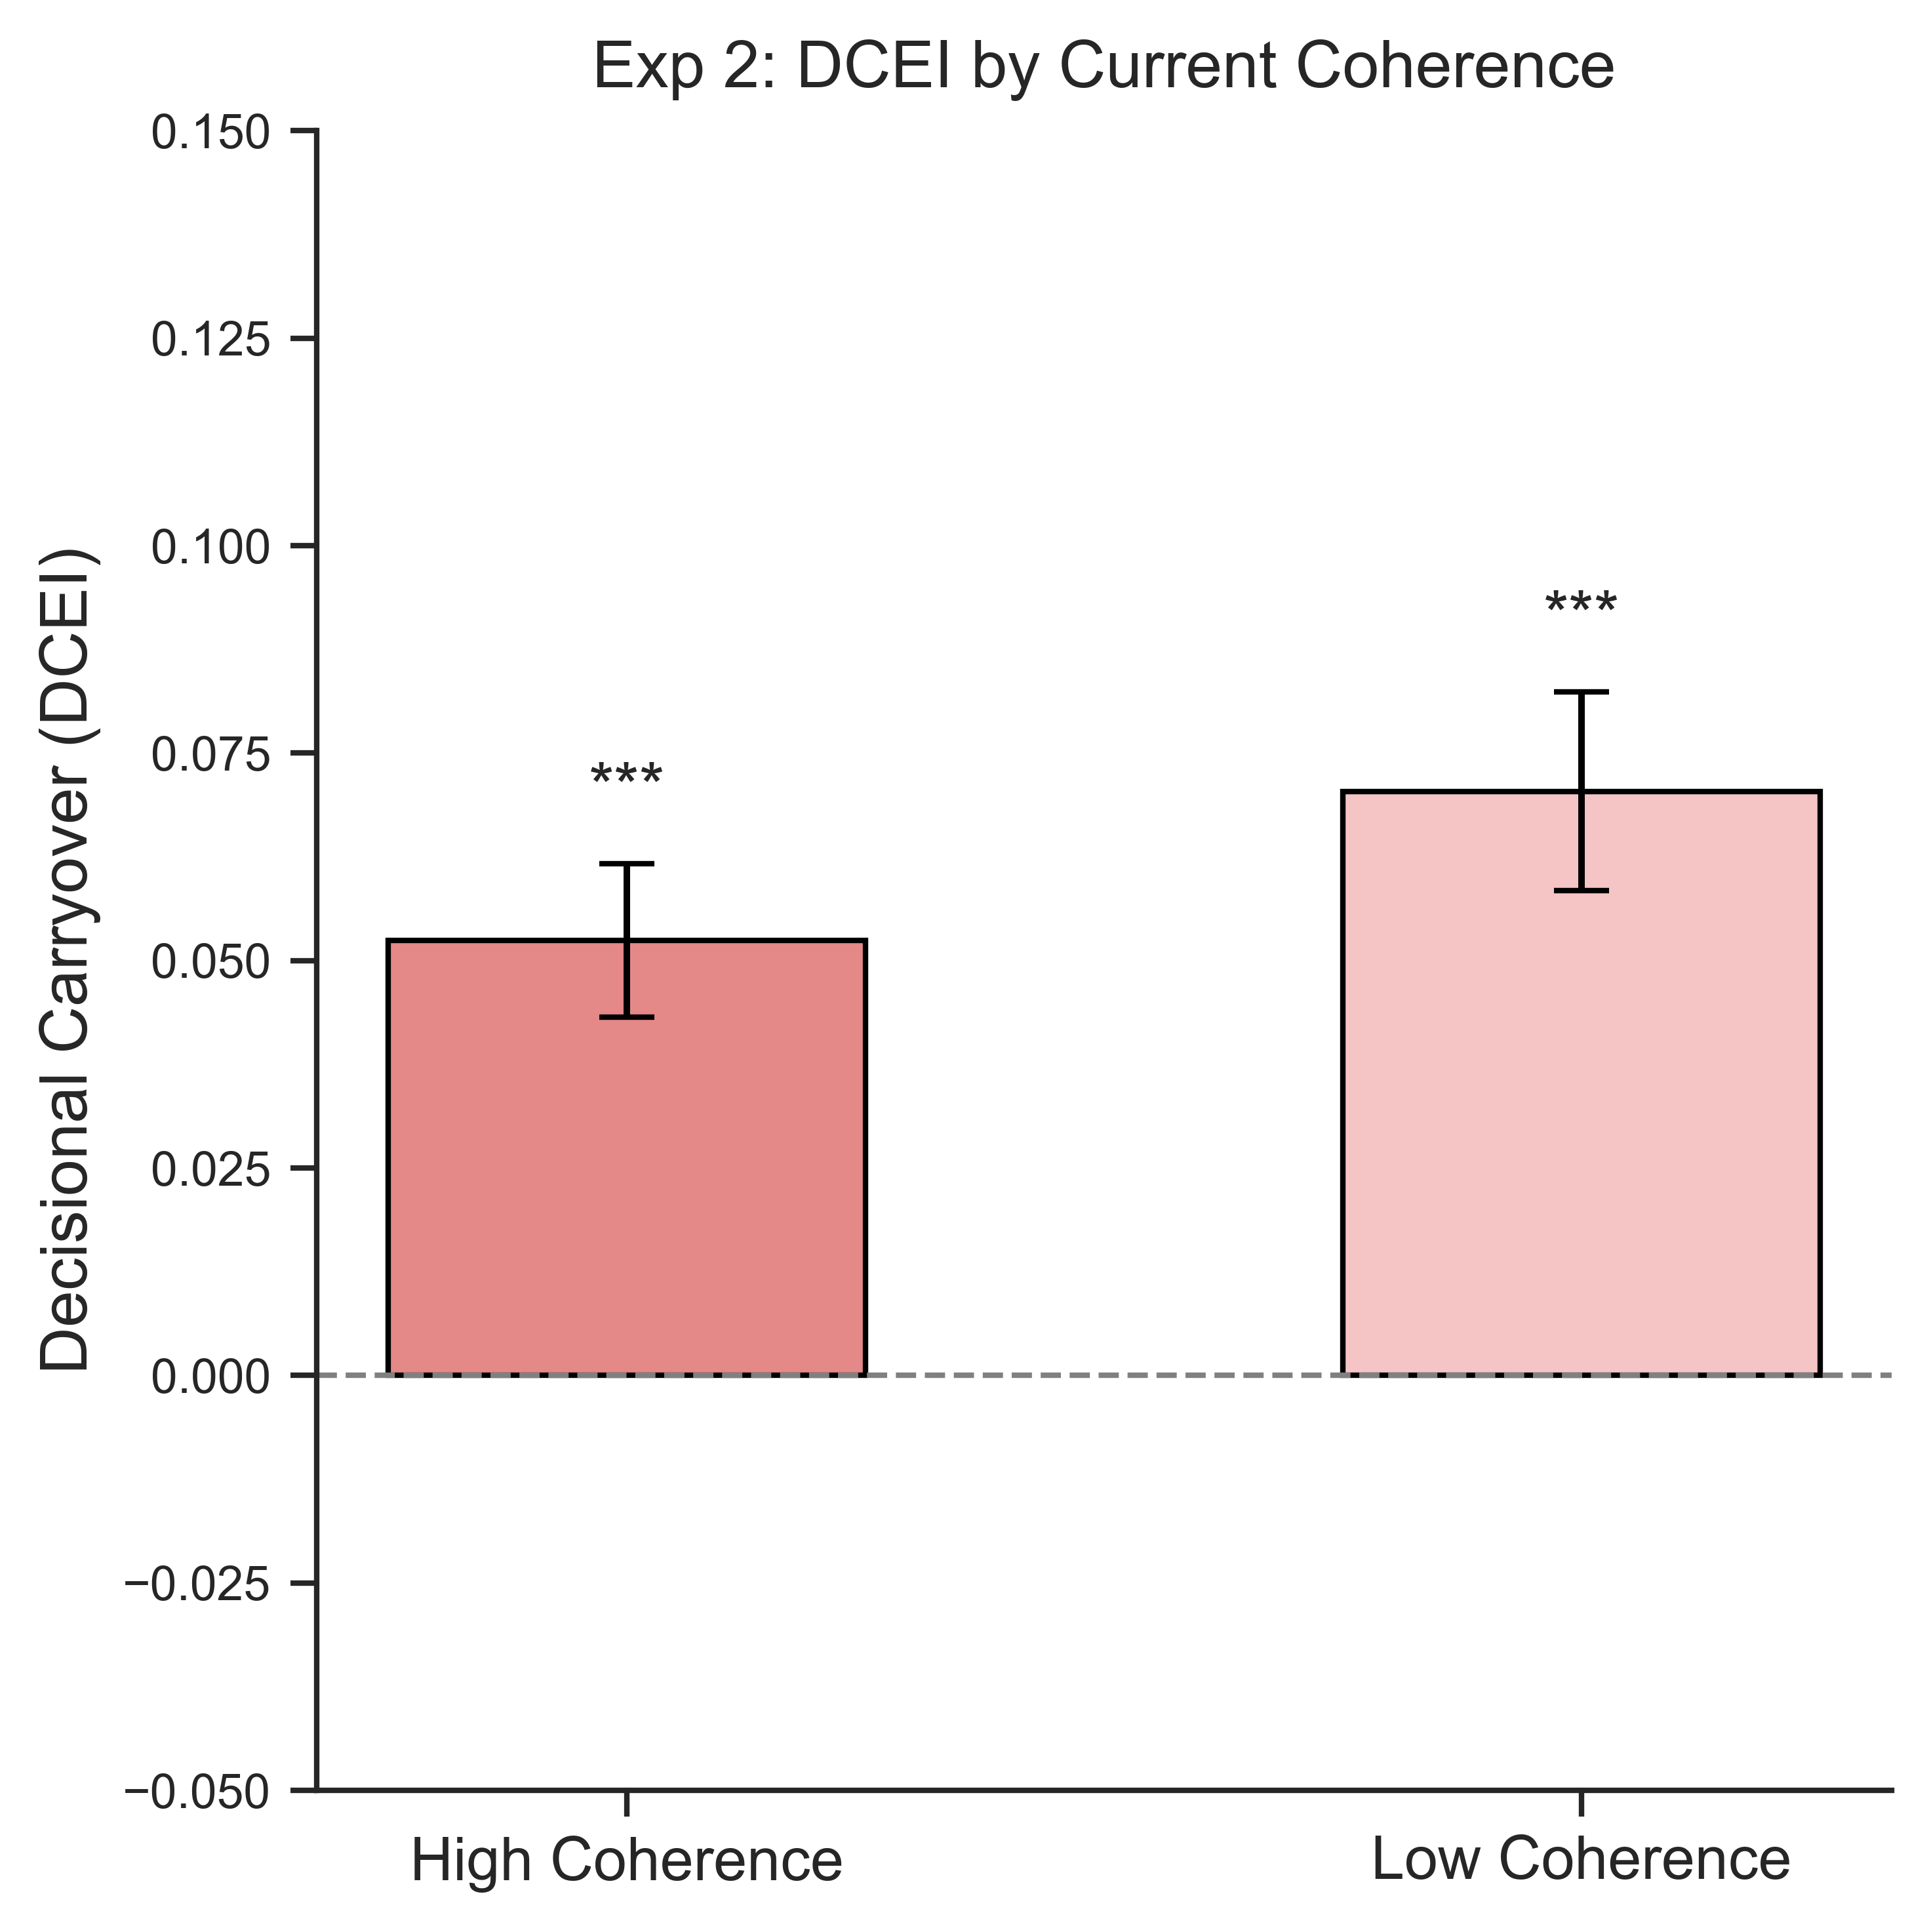

In [ ]:
# Visualization: DCEI bar plot by Current Coherence
fig, ax = plt.subplots(figsize=(5, 5))

conditions = ['High', 'Low']
means = [stats_results[c]['mean'] for c in conditions]
sems = [stats_results[c]['sem'] for c in conditions]
colors = ['#e58888', '#f5c4c4']

x = np.arange(len(conditions))
bars = ax.bar(x, means, yerr=sems, capsize=5, color=colors, width=0.5, edgecolor='black', linewidth=1)

# Add significance markers
for i, cond in enumerate(conditions):
    p = stats_results[cond]['p']
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ax.text(i, means[i] + sems[i] + 0.005, sig, ha='center', va='bottom', fontsize=12)
ax.set_ylim(-0.05, 0.15)
ax.axhline(0, ls='--', color='gray', lw=1)
ax.set_ylabel('Decisional Carryover (DCEI)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(['High Coherence', 'Low Coherence'], fontsize=11)
ax.set_title('Exp 2: DCEI by Current Coherence', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## Repeated Measures ANOVA Summary

Comprehensive RM ANOVA analyses for CTI, SDI, Bias, and RT with consistent η² (partial eta-squared) reporting.

In [ ]:
# =============================================================================
# COMPREHENSIVE RM ANOVA ANALYSIS - EXPERIMENT 2
# =============================================================================

# Reload clean data
df_exp2 = pd.read_pickle('E1.pkl')
df_exp2 = df_exp2[df_exp2['is_outlier'] == False].copy()

# Map coherence values to labels (0.3 = Low coherence, 0.7 = High coherence)
coherence_map = {0.3: 'Low', 0.7: 'High'}
df_exp2['prior'] = df_exp2['preCoherence1back'].map(coherence_map)
df_exp2['current'] = df_exp2['curCoherence'].map(coherence_map)

# --- 1. Calculate CTI and Bias Intercept per subject × prior × current ---
print("=" * 70)
print("1. CENTRAL TENDENCY INDEX (CTI) & BIAS INTERCEPT")
print("=" * 70)

ct_results = []
for (sub_id, prior, current), subdf in df_exp2.groupby(['subID', 'prior', 'current']):
    if subdf['curDur'].nunique() >= 3:
        X = sm.add_constant(subdf['curDur'])
        y = subdf['curBias']
        model = sm.OLS(y, X).fit()
        slope = model.params['curDur']
        intercept = model.params['const']
        ct_results.append({
            'subID': sub_id,
            'prior': prior,
            'current': current,
            'CTI': abs(slope),     # Central Tendency Index
            'intercept': intercept  # Bias intercept
        })
df_ct = pd.DataFrame(ct_results)

# 2×2 RM ANOVA for CTI
print("\n--- CTI: 2×2 RM ANOVA (Prior × Current Coherence) ---")
aov_cti = pg.rm_anova(data=df_ct, dv='CTI', within=['prior', 'current'], 
                       subject='subID', detailed=True, effsize='np2')
print(aov_cti[['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']].to_string(index=False))

# Summary statistics
print("\nCTI Summary by Condition:")
cti_summary = df_ct.groupby(['prior', 'current']).agg(
    Mean=('CTI', 'mean'), SEM=('CTI', 'sem'), N=('subID', 'nunique')
).round(4)
print(cti_summary)

# 2×2 RM ANOVA for Bias Intercept
print("\n--- Bias Intercept: 2×2 RM ANOVA (Prior × Current Coherence) ---")
aov_bias = pg.rm_anova(data=df_ct, dv='intercept', within=['prior', 'current'], 
                        subject='subID', detailed=True, effsize='np2')
print(aov_bias[['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']].to_string(index=False))

# Summary statistics
print("\nBias Intercept Summary by Condition:")
bias_summary = df_ct.groupby(['prior', 'current']).agg(
    Mean=('intercept', 'mean'), SEM=('intercept', 'sem'), N=('subID', 'nunique')
).round(4)
print(bias_summary)

1. CENTRAL TENDENCY INDEX (CTI) & BIAS INTERCEPT

--- CTI: 2×2 RM ANOVA (Prior × Current Coherence) ---
         Source  ddof1  ddof2        F    p_unc          np2
          prior      1     21 0.000011 0.997435 5.039665e-07
        current      1     21 0.047886 0.828897 2.275078e-03
prior * current      1     21 3.251988 0.085705 1.340916e-01

CTI Summary by Condition:
                 Mean     SEM   N
prior current                    
High  High     0.4028  0.0426  22
      Low      0.3621  0.0489  22
Low   High     0.3677  0.0426  22
      Low      0.3970  0.0436  22

--- Bias Intercept: 2×2 RM ANOVA (Prior × Current Coherence) ---
         Source  ddof1  ddof2        F    p_unc      np2
          prior      1     21 0.003618 0.952602 0.000172
        current      1     21 7.568631 0.011969 0.264928
prior * current      1     21 4.296160 0.050697 0.169834

Bias Intercept Summary by Condition:
                 Mean     SEM   N
prior current                    
High  High     0.6211

In [ ]:
# --- 2. Serial Dependence Index (SDI) Analysis ---
print("=" * 70)
print("2. SERIAL DEPENDENCE INDEX (SDI)")
print("=" * 70)

# Calculate SDI: slope of curBias ~ preDur for each subject × prior × current
sdi_results = []
for (sub_id, prior, current), subdf in df_exp2.groupby(['subID', 'prior', 'current']):
    if subdf['preDur1back'].nunique() >= 3:
        X = sm.add_constant(subdf['preDur1back'])
        y = subdf['curBias']
        model = sm.OLS(y, X).fit()
        slope = model.params['preDur1back']
        sdi_results.append({
            'subID': sub_id,
            'prior': prior,
            'current': current,
            'SDI': slope
        })
df_sdi = pd.DataFrame(sdi_results)

# 2×2 RM ANOVA for SDI
print("\n--- SDI: 2×2 RM ANOVA (Prior × Current Coherence) ---")
aov_sdi = pg.rm_anova(data=df_sdi, dv='SDI', within=['prior', 'current'], 
                       subject='subID', detailed=True, effsize='np2')
print(aov_sdi[['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']].to_string(index=False))

# Summary statistics
print("\nSDI Summary by Condition:")
sdi_summary = df_sdi.groupby(['prior', 'current']).agg(
    Mean=('SDI', 'mean'), SEM=('SDI', 'sem'), N=('subID', 'nunique')
).round(4)
print(sdi_summary)

# Post-hoc pairwise comparisons (Bonferroni corrected)
print("\n--- Post-hoc Pairwise Comparisons (Bonferroni corrected) ---")
# Create TransitionType column (now prior/current are strings)
df_sdi['TransitionType'] = df_sdi['prior'] + '-' + df_sdi['current']
posthoc = pg.pairwise_tests(data=df_sdi, dv='SDI', within='TransitionType', 
                             subject='subID', padjust='bonf')
print(posthoc[['A', 'B', 'T', 'p_unc', 'p_corr', 'hedges']].to_string(index=False))

2. SERIAL DEPENDENCE INDEX (SDI)

--- SDI: 2×2 RM ANOVA (Prior × Current Coherence) ---


         Source  ddof1  ddof2        F    p_unc      np2
          prior      1     21 0.062578 0.804898 0.002971
        current      1     21 8.214185 0.009248 0.281171
prior * current      1     21 2.365932 0.138942 0.101256

SDI Summary by Condition:
                 Mean     SEM   N
prior current                    
High  High     0.0350  0.0239  22
      Low      0.0676  0.0194  22
Low   High     0.0015  0.0165  22
      Low      0.0919  0.0159  22

--- Post-hoc Pairwise Comparisons (Bonferroni corrected) ---
        A        B         T    p_unc   p_corr    hedges
High-High High-Low -0.945642 0.355086 1.000000 -0.313471
High-High Low-High  1.182574 0.250195 1.000000  0.341836
High-High  Low-Low -1.901702 0.071018 0.426109 -0.587517
 High-Low Low-High  2.510607 0.020307 0.121843  0.768869
 High-Low  Low-Low -1.017218 0.320627 1.000000 -0.287363
 Low-High  Low-Low -4.308420 0.000311 0.001865 -1.170323


In [ ]:
# --- 3. Current Coherence Analysis (Key for Exp2) ---
print("=" * 70)
print("3. SDI BY CURRENT COHERENCE (High vs Low Coherence)")
print("=" * 70)

# Aggregate SDI by current coherence per subject
df_sdi_cur = df_sdi.groupby(['subID', 'current'])['SDI'].mean().reset_index()

# RM ANOVA: Current Coherence (High vs Low)
print("\n--- SDI: RM ANOVA (Current Coherence) ---")
aov_cur = pg.rm_anova(data=df_sdi_cur, dv='SDI', within='current', 
                       subject='subID', detailed=True, effsize='np2')
# One-way ANOVA uses 'DF' not 'ddof1'/'ddof2'
print(aov_cur[['Source', 'DF', 'F', 'p_unc', 'np2']].to_string(index=False))

# Paired t-test
sdi_high = df_sdi_cur[df_sdi_cur['current'] == 'High'].set_index('subID')['SDI']
sdi_low = df_sdi_cur[df_sdi_cur['current'] == 'Low'].set_index('subID')['SDI']
t_cur, p_cur = ttest_rel(sdi_high, sdi_low)
d_cur = (sdi_high.mean() - sdi_low.mean()) / np.sqrt((sdi_high.std()**2 + sdi_low.std()**2) / 2)

print(f"\nPaired t-test (High vs Low Coherence):")
print(f"  High Coherence (0.7): M = {sdi_high.mean():.4f}, SD = {sdi_high.std():.4f}")
print(f"  Low Coherence (0.3):  M = {sdi_low.mean():.4f}, SD = {sdi_low.std():.4f}")
print(f"  t({len(sdi_high)-1}) = {t_cur:.2f}, p = {p_cur:.4f}, d = {d_cur:.3f}")
print(f"\n  Note: High = high coherence (0.7, clearer stimulus)")
print(f"        Low = low coherence (0.3, noisier stimulus)")

3. SDI BY CURRENT COHERENCE (High vs Low Coherence)

--- SDI: RM ANOVA (Current Coherence) ---
 Source  DF        F    p_unc      np2
current   1 8.214185 0.009248 0.281171
  Error  21      NaN      NaN      NaN

Paired t-test (High vs Low Coherence):
  High Coherence (0.7): M = 0.0183, SD = 0.0696
  Low Coherence (0.3):  M = 0.0797, SD = 0.0614
  t(21) = -2.87, p = 0.0092, d = -0.937

  Note: High = high coherence (0.7, clearer stimulus)
        Low = low coherence (0.3, noisier stimulus)


In [ ]:
# --- 5. ANOVA SUMMARY TABLE (for Manuscript) ---
print("=" * 70)
print("5. RM ANOVA SUMMARY TABLE (EXPERIMENT 2)")
print("=" * 70)
print("\nFormat: F(df1, df2) = F-value, p = p-value, η² = effect_size\n")

def format_anova_result_2way(aov, source_idx):
    """Format 2-way ANOVA result for manuscript reporting."""
    row = aov.iloc[source_idx]
    f_val = row['F']
    p_val = row['p_unc']
    eta2 = row['np2']
    df1 = int(row['ddof1'])
    df2 = int(row['ddof2'])
    p_str = f"p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
    return f"F({df1}, {df2}) = {f_val:.2f}, {p_str}, η² = {eta2:.3f}"

def format_anova_result_1way(aov):
    """Format 1-way ANOVA result for manuscript reporting."""
    row = aov.iloc[0]  # First row is the effect
    f_val = row['F']
    p_val = row['p_unc']
    eta2 = row['np2']
    df1 = int(row['DF'])
    df2 = int(aov.iloc[1]['DF'])  # Second row is Error
    p_str = f"p < .001" if p_val < 0.001 else f"p = {p_val:.3f}"
    return f"F({df1}, {df2}) = {f_val:.2f}, {p_str}, η² = {eta2:.3f}"

# Collect all results
results_table = []

# CTI ANOVA
for i, source in enumerate(['prior', 'current', 'prior × current']):
    results_table.append({
        'DV': 'CTI' if i == 0 else '',
        'Effect': source,
        'Result': format_anova_result_2way(aov_cti, i)
    })

# Bias Intercept ANOVA
for i, source in enumerate(['prior', 'current', 'prior × current']):
    results_table.append({
        'DV': 'Bias Intercept' if i == 0 else '',
        'Effect': source,
        'Result': format_anova_result_2way(aov_bias, i)
    })

# SDI ANOVA
for i, source in enumerate(['prior', 'current', 'prior × current']):
    results_table.append({
        'DV': 'SDI' if i == 0 else '',
        'Effect': source,
        'Result': format_anova_result_2way(aov_sdi, i)
    })

# Current Coherence only
results_table.append({
    'DV': 'SDI (Current)',
    'Effect': 'Current Coherence',
    'Result': format_anova_result_1way(aov_cur)
})

df_summary_table = pd.DataFrame(results_table)
print(df_summary_table.to_string(index=False))

print("\n" + "=" * 70)
print("KEY FINDINGS FOR MANUSCRIPT:")
print("=" * 70)
print(f"\n1. SDI Current Main Effect: {format_anova_result_2way(aov_sdi, 1)}")
print(f"2. Bias Intercept Current Main Effect: {format_anova_result_2way(aov_bias, 1)}")
print(f"3. SDI by Current Coherence: {format_anova_result_1way(aov_cur)}")
print(f"   - High Coherence (0.7): M = {sdi_high.mean():.3f}, SD = {sdi_high.std():.3f}")
print(f"   - Low Coherence (0.3): M = {sdi_low.mean():.3f}, SD = {sdi_low.std():.3f}")
print(f"   - Paired t-test: t({len(sdi_high)-1}) = {t_cur:.2f}, p = {p_cur:.4f}, d = {d_cur:.3f}")

5. RM ANOVA SUMMARY TABLE (EXPERIMENT 2)

Format: F(df1, df2) = F-value, p = p-value, η² = effect_size

            DV            Effect                                 Result
           CTI             prior F(1, 21) = 0.00, p = 0.997, η² = 0.000
                         current F(1, 21) = 0.05, p = 0.829, η² = 0.002
                 prior × current F(1, 21) = 3.25, p = 0.086, η² = 0.134
Bias Intercept             prior F(1, 21) = 0.00, p = 0.953, η² = 0.000
                         current F(1, 21) = 7.57, p = 0.012, η² = 0.265
                 prior × current F(1, 21) = 4.30, p = 0.051, η² = 0.170
           SDI             prior F(1, 21) = 0.06, p = 0.805, η² = 0.003
                         current F(1, 21) = 8.21, p = 0.009, η² = 0.281
                 prior × current F(1, 21) = 2.37, p = 0.139, η² = 0.101
 SDI (Current) Current Coherence F(1, 21) = 8.21, p = 0.009, η² = 0.281

KEY FINDINGS FOR MANUSCRIPT:

1. SDI Current Main Effect: F(1, 21) = 8.21, p = 0.009, η² = 0.281
2. Bia

In [ ]:
# --- 6. One-way RM ANOVA for Transition Type (as reported in manuscript) ---
print("=" * 70)
print("6. ONE-WAY RM ANOVA: SDI BY TRANSITION TYPE (HH, HL, LH, LL)")
print("=" * 70)

# One-way RM ANOVA with 4 levels
aov_trans = pg.rm_anova(data=df_sdi, dv='SDI', within='TransitionType', 
                         subject='subID', detailed=True, effsize='np2')
print("\n--- SDI: One-way RM ANOVA (Transition Type) ---")
print(aov_trans[['Source', 'DF', 'F', 'p_unc', 'np2', 'eps']].to_string(index=False))

# Check sphericity
sph = pg.sphericity(data=df_sdi, dv='SDI', subject='subID', within='TransitionType')
print(f"\nSphericity test: W = {sph[1]:.3f}, p = {sph[2]:.4f}")
if sph[0]:
    print("  Sphericity assumption met.")
else:
    print("  Sphericity violated - Greenhouse-Geisser correction applied.")
    print(f"  Epsilon = {aov_trans['eps'].values[0]:.3f}")

# Summary by TransitionType
print("\nSDI by Transition Type:")
trans_summary = df_sdi.groupby('TransitionType')['SDI'].agg(['mean', 'std', 'sem']).round(4)
print(trans_summary)

6. ONE-WAY RM ANOVA: SDI BY TRANSITION TYPE (HH, HL, LH, LL)

--- SDI: One-way RM ANOVA (Transition Type) ---
        Source  DF        F   p_unc      np2     eps
TransitionType   3 4.042012 0.01081 0.161409 0.82872
         Error  63      NaN     NaN      NaN     NaN

Sphericity test: W = 0.738, p = 5.9787
  Sphericity assumption met.

SDI by Transition Type:
                  mean     std     sem
TransitionType                        
High-High       0.0350  0.1120  0.0239
High-Low        0.0676  0.0910  0.0194
Low-High        0.0015  0.0772  0.0165
Low-Low         0.0919  0.0745  0.0159


---
## T-tests for Manuscript (with Bonferroni Correction)

This section consolidates all t-tests reported in the manuscript.

In [ ]:
# =============================================================================
# T-TESTS FOR MANUSCRIPT - EXPERIMENT 2
# =============================================================================

# Reload and prepare data
df_exp2 = pd.read_pickle('E1.pkl')
df_exp2 = df_exp2[df_exp2['is_outlier'] == False].copy()

# Map coherence values (0.3 = Low coherence, 0.7 = High coherence)
coherence_map = {0.3: 'Low', 0.7: 'High'}  # High/Low refers to COHERENCE level
df_exp2['prior'] = df_exp2['preCoherence1back'].map(coherence_map)
df_exp2['current'] = df_exp2['curCoherence'].map(coherence_map)

# --- Calculate CTI per subject × condition ---
ct_results = []
for (sub_id, prior, current), subdf in df_exp2.groupby(['subID', 'prior', 'current']):
    if subdf['curDur'].nunique() >= 3:
        X = sm.add_constant(subdf['curDur'])
        y = subdf['curBias']
        model = sm.OLS(y, X).fit()
        ct_results.append({
            'subID': sub_id,
            'prior': prior,
            'current': current,
            'CTI': abs(model.params['curDur']),
            'intercept': model.params['const']
        })
df_ct = pd.DataFrame(ct_results)
df_ct['SameSwitch'] = df_ct.apply(lambda row: 'Same' if row['prior'] == row['current'] else 'Switch', axis=1)
df_ct['TransitionType'] = df_ct['prior'] + '-' + df_ct['current']

# --- Calculate SDI per subject × condition ---
sdi_results = []
for (sub_id, prior, current), subdf in df_exp2.groupby(['subID', 'prior', 'current']):
    if subdf['preDur1back'].nunique() >= 3:
        X = sm.add_constant(subdf['preDur1back'])
        y = subdf['curBias']
        model = sm.OLS(y, X).fit()
        sdi_results.append({
            'subID': sub_id,
            'prior': prior,
            'current': current,
            'SDI': model.params['preDur1back']
        })
df_sdi = pd.DataFrame(sdi_results)
df_sdi['SameSwitch'] = df_sdi.apply(lambda row: 'Same' if row['prior'] == row['current'] else 'Switch', axis=1)
df_sdi['TransitionType'] = df_sdi['prior'] + '-' + df_sdi['current']

print("Data prepared successfully!")
print(f"CTI data: {len(df_ct)} observations, {df_ct['subID'].nunique()} subjects")
print(f"SDI data: {len(df_sdi)} observations, {df_sdi['subID'].nunique()} subjects")

Data prepared successfully!
CTI data: 88 observations, 22 subjects
SDI data: 88 observations, 22 subjects


In [ ]:
# =============================================================================
# 1. CTI T-TESTS
# =============================================================================

print("=" * 70)
print("1. CTI T-TESTS")
print("=" * 70)

# --- 1a. CTI: High vs Low Uncertainty (Current) ---
print("\n--- 1a. CTI: High vs Low Uncertainty (Current Coherence) ---")
df_cti_cur = df_ct.groupby(['subID', 'current'])['CTI'].mean().reset_index()
cti_high = df_cti_cur[df_cti_cur['current'] == 'High'].set_index('subID')['CTI']
cti_low = df_cti_cur[df_cti_cur['current'] == 'Low'].set_index('subID')['CTI']
common = cti_high.index.intersection(cti_low.index)

t_cti_hl, p_cti_hl = ttest_rel(cti_high.loc[common], cti_low.loc[common])
d_cti_hl = (cti_high.loc[common].mean() - cti_low.loc[common].mean()) / np.sqrt(
    (cti_high.loc[common].std()**2 + cti_low.loc[common].std()**2) / 2)

print(f"High Uncertainty (0.3 coh): M = {cti_high.loc[common].mean():.3f}, SD = {cti_high.loc[common].std():.3f}")
print(f"Low Uncertainty (0.7 coh):  M = {cti_low.loc[common].mean():.3f}, SD = {cti_low.loc[common].std():.3f}")
print(f"t({len(common)-1}) = {t_cti_hl:.2f}, p = {p_cti_hl:.3f}, d = {d_cti_hl:.3f}")

# --- 1b. CTI: Pairwise comparisons (4 transition types) ---
print("\n--- 1b. CTI: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---")
df_cti_trans = df_ct.groupby(['subID', 'TransitionType'])['CTI'].mean().reset_index()
transitions = ['High-High', 'High-Low', 'Low-High', 'Low-Low']
n_comparisons = 6

cti_pairwise = []
for i, t1 in enumerate(transitions):
    for t2 in transitions[i+1:]:
        v1 = df_cti_trans[df_cti_trans['TransitionType'] == t1].set_index('subID')['CTI']
        v2 = df_cti_trans[df_cti_trans['TransitionType'] == t2].set_index('subID')['CTI']
        common_subs = v1.index.intersection(v2.index)
        t_stat, p_val = ttest_rel(v1.loc[common_subs], v2.loc[common_subs])
        p_bonf = min(p_val * n_comparisons, 1.0)
        cti_pairwise.append({
            'Comparison': f'{t1} vs {t2}',
            't': t_stat,
            'df': len(common_subs) - 1,
            'p_uncorr': p_val,
            'p_bonf': p_bonf,
            'sig': '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'n.s.'
        })

df_cti_pairwise = pd.DataFrame(cti_pairwise)
print(df_cti_pairwise.to_string(index=False))

1. CTI T-TESTS

--- 1a. CTI: High vs Low Uncertainty (Current Coherence) ---
High Uncertainty (0.3 coh): M = 0.385, SD = 0.189
Low Uncertainty (0.7 coh):  M = 0.380, SD = 0.203
t(21) = 0.22, p = 0.829, d = 0.029

--- 1b. CTI: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---
           Comparison         t  df  p_uncorr  p_bonf  sig
High-High vs High-Low  1.305783  21  0.205750     1.0 n.s.
High-High vs Low-High  1.263752  21  0.220168     1.0 n.s.
 High-High vs Low-Low  0.149624  21  0.882489     1.0 n.s.
 High-Low vs Low-High -0.174850  21  0.862872     1.0 n.s.
  High-Low vs Low-Low -1.041870  21  0.309319     1.0 n.s.
  Low-High vs Low-Low -0.881473  21  0.388040     1.0 n.s.


In [ ]:
# =============================================================================
# 1c. BIAS INTERCEPT T-TESTS (Important for Exp2)
# =============================================================================

print("=" * 70)
print("1c. BIAS INTERCEPT T-TESTS")
print("=" * 70)

# --- Intercept: Pairwise comparisons (4 transition types) ---
print("\n--- Intercept: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---")
df_int_trans = df_ct.groupby(['subID', 'TransitionType'])['intercept'].mean().reset_index()
transitions = ['High-High', 'High-Low', 'Low-High', 'Low-Low']
n_comparisons = 6

int_pairwise = []
for i, t1 in enumerate(transitions):
    for t2 in transitions[i+1:]:
        v1 = df_int_trans[df_int_trans['TransitionType'] == t1].set_index('subID')['intercept']
        v2 = df_int_trans[df_int_trans['TransitionType'] == t2].set_index('subID')['intercept']
        common_subs = v1.index.intersection(v2.index)
        t_stat, p_val = ttest_rel(v1.loc[common_subs], v2.loc[common_subs])
        p_bonf = min(p_val * n_comparisons, 1.0)
        int_pairwise.append({
            'Comparison': f'{t1} vs {t2}',
            't': t_stat,
            'df': len(common_subs) - 1,
            'p_uncorr': p_val,
            'p_bonf': p_bonf,
            'sig': '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'n.s.'
        })

df_int_pairwise = pd.DataFrame(int_pairwise)
print(df_int_pairwise.to_string(index=False))

1c. BIAS INTERCEPT T-TESTS

--- Intercept: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---
           Comparison         t  df  p_uncorr   p_bonf  sig
High-High vs High-Low  4.032106  21  0.000602 0.003610   **
High-High vs Low-High  1.465961  21  0.157473 0.944841 n.s.
 High-High vs Low-Low  1.969040  21  0.062286 0.373713 n.s.
 High-Low vs Low-High -2.323146  21  0.030295 0.181768 n.s.
  High-Low vs Low-Low -1.103717  21  0.282203 1.000000 n.s.
  Low-High vs Low-Low  1.074048  21  0.294988 1.000000 n.s.


In [ ]:
# =============================================================================
# 2. SDI T-TESTS
# =============================================================================

print("=" * 70)
print("2. SDI T-TESTS")
print("=" * 70)

# --- 2a. SDI: High vs Low Uncertainty (Current) - KEY RESULT for Exp2 ---
print("\n--- 2a. SDI: High vs Low Uncertainty (Current Coherence) ---")
df_sdi_cur = df_sdi.groupby(['subID', 'current'])['SDI'].mean().reset_index()
sdi_high = df_sdi_cur[df_sdi_cur['current'] == 'High'].set_index('subID')['SDI']
sdi_low = df_sdi_cur[df_sdi_cur['current'] == 'Low'].set_index('subID')['SDI']
common = sdi_high.index.intersection(sdi_low.index)

t_sdi_hl, p_sdi_hl = ttest_rel(sdi_high.loc[common], sdi_low.loc[common])
d_sdi_hl = (sdi_high.loc[common].mean() - sdi_low.loc[common].mean()) / np.sqrt(
    (sdi_high.loc[common].std()**2 + sdi_low.loc[common].std()**2) / 2)

print(f"High Uncertainty (0.3 coh): M = {sdi_high.loc[common].mean():.3f}, SD = {sdi_high.loc[common].std():.3f}")
print(f"Low Uncertainty (0.7 coh):  M = {sdi_low.loc[common].mean():.3f}, SD = {sdi_low.loc[common].std():.3f}")
print(f"t({len(common)-1}) = {t_sdi_hl:.2f}, p = {p_sdi_hl:.4f}, d = {d_sdi_hl:.3f}")

# --- 2b. SDI: Same vs Switch ---
print("\n--- 2b. SDI: Same vs Switch ---")
df_sdi_ss = df_sdi.groupby(['subID', 'SameSwitch'])['SDI'].mean().reset_index()
sdi_same = df_sdi_ss[df_sdi_ss['SameSwitch'] == 'Same'].set_index('subID')['SDI']
sdi_switch = df_sdi_ss[df_sdi_ss['SameSwitch'] == 'Switch'].set_index('subID')['SDI']
common_ss = sdi_same.index.intersection(sdi_switch.index)

t_sdi_ss, p_sdi_ss = ttest_rel(sdi_same.loc[common_ss], sdi_switch.loc[common_ss])
d_sdi_ss = (sdi_same.loc[common_ss].mean() - sdi_switch.loc[common_ss].mean()) / np.sqrt(
    (sdi_same.loc[common_ss].std()**2 + sdi_switch.loc[common_ss].std()**2) / 2)

print(f"Same (HH, LL):   M = {sdi_same.loc[common_ss].mean():.3f}, SD = {sdi_same.loc[common_ss].std():.3f}")
print(f"Switch (HL, LH): M = {sdi_switch.loc[common_ss].mean():.3f}, SD = {sdi_switch.loc[common_ss].std():.3f}")
print(f"t({len(common_ss)-1}) = {t_sdi_ss:.2f}, p = {p_sdi_ss:.4f}, d = {d_sdi_ss:.3f}")

2. SDI T-TESTS

--- 2a. SDI: High vs Low Uncertainty (Current Coherence) ---
High Uncertainty (0.3 coh): M = 0.018, SD = 0.070
Low Uncertainty (0.7 coh):  M = 0.080, SD = 0.061
t(21) = -2.87, p = 0.0092, d = -0.937

--- 2b. SDI: Same vs Switch ---
Same (HH, LL):   M = 0.063, SD = 0.064
Switch (HL, LH): M = 0.035, SD = 0.058
t(21) = 1.54, p = 0.1389, d = 0.474


In [ ]:
# =============================================================================
# 2c. SDI PAIRWISE COMPARISONS
# =============================================================================

print("=" * 70)
print("2c. SDI PAIRWISE COMPARISONS")
print("=" * 70)

# --- SDI: Pairwise comparisons (4 transition types, 6 comparisons) ---
print("\n--- SDI: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---")
df_sdi_trans = df_sdi.groupby(['subID', 'TransitionType'])['SDI'].mean().reset_index()
transitions = ['High-High', 'High-Low', 'Low-High', 'Low-Low']
n_comparisons = 6

sdi_pairwise = []
for i, t1 in enumerate(transitions):
    for t2 in transitions[i+1:]:
        v1 = df_sdi_trans[df_sdi_trans['TransitionType'] == t1].set_index('subID')['SDI']
        v2 = df_sdi_trans[df_sdi_trans['TransitionType'] == t2].set_index('subID')['SDI']
        common_subs = v1.index.intersection(v2.index)
        t_stat, p_val = ttest_rel(v1.loc[common_subs], v2.loc[common_subs])
        p_bonf = min(p_val * n_comparisons, 1.0)
        sdi_pairwise.append({
            'Comparison': f'{t1} vs {t2}',
            't': t_stat,
            'df': len(common_subs) - 1,
            'p_uncorr': p_val,
            'p_bonf': p_bonf,
            'sig': '***' if p_bonf < 0.001 else '**' if p_bonf < 0.01 else '*' if p_bonf < 0.05 else 'n.s.'
        })

df_sdi_pairwise = pd.DataFrame(sdi_pairwise)
print(df_sdi_pairwise.to_string(index=False))

2c. SDI PAIRWISE COMPARISONS

--- SDI: Pairwise Comparisons (Bonferroni corrected, 6 comparisons) ---
           Comparison         t  df  p_uncorr   p_bonf  sig
High-High vs High-Low -0.945642  21  0.355086 1.000000 n.s.
High-High vs Low-High  1.182574  21  0.250195 1.000000 n.s.
 High-High vs Low-Low -1.901702  21  0.071018 0.426109 n.s.
 High-Low vs Low-High  2.510607  21  0.020307 0.121843 n.s.
  High-Low vs Low-Low -1.017218  21  0.320627 1.000000 n.s.
  Low-High vs Low-Low -4.308420  21  0.000311 0.001865   **


In [ ]:
# =============================================================================
# 3. SUMMARY TABLE FOR MANUSCRIPT
# =============================================================================

print("=" * 70)
print("EXPERIMENT 2: T-TEST SUMMARY FOR MANUSCRIPT")
print("=" * 70)

summary_data = [
    {'Test': 'CTI High vs Low', 
     't': t_cti_hl, 'df': len(common)-1, 
     'p': p_cti_hl, 'd': d_cti_hl,
     'Note': 'Central tendency similar across coherence levels'},
    {'Test': 'SDI High vs Low', 
     't': t_sdi_hl, 'df': len(common)-1, 
     'p': p_sdi_hl, 'd': d_sdi_hl,
     'Note': 'KEY: High > Low (sensory weighting)'},
    {'Test': 'SDI Same vs Switch', 
     't': t_sdi_ss, 'df': len(common_ss)-1, 
     'p': p_sdi_ss, 'd': d_sdi_ss,
     'Note': 'Trend only (p = .09 in manuscript)'},
]

# Add significant SDI pairwise comparisons
for row in sdi_pairwise:
    if row['p_bonf'] < 0.05:
        summary_data.append({
            'Test': f"SDI {row['Comparison']}", 
            't': row['t'], 'df': row['df'],
            'p': row['p_bonf'], 'd': np.nan,
            'Note': 'Bonferroni corrected'
        })

# Add significant intercept comparisons
for row in int_pairwise:
    if row['p_uncorr'] < 0.01:  # Use uncorrected for intercept as in manuscript
        summary_data.append({
            'Test': f"Intercept {row['Comparison']}", 
            't': row['t'], 'df': row['df'],
            'p': row['p_uncorr'], 'd': np.nan,
            'Note': 'p uncorrected (as in manuscript)'
        })

df_summary = pd.DataFrame(summary_data)
print("\n")
print(df_summary.to_string(index=False))

print("\n" + "=" * 70)
print("KEY FINDINGS:")
print("=" * 70)
print(f"1. CTI High vs Low: t({len(common)-1}) = {t_cti_hl:.2f}, p = {p_cti_hl:.3f}")
print(f"   → No difference in central tendency between coherence levels")
print(f"\n2. SDI High vs Low: t({len(common)-1}) = {t_sdi_hl:.2f}, p = {p_sdi_hl:.4f}, d = {d_sdi_hl:.3f}")
print(f"   → Low coherence shows STRONGER serial dependence")
print(f"   → Supports sensory weighting mechanism")
print(f"\n3. Bias Intercept: LL vs LH effect suggests prior coherence affects overall bias")

EXPERIMENT 2: T-TEST SUMMARY FOR MANUSCRIPT


                           Test         t  df        p         d                                             Note
                CTI High vs Low  0.218828  21 0.828897  0.028762 Central tendency similar across coherence levels
                SDI High vs Low -2.866040  21 0.009248 -0.936999              KEY: High > Low (sensory weighting)
             SDI Same vs Switch  1.538159  21 0.138942  0.474145               Trend only (p = .09 in manuscript)
        SDI Low-High vs Low-Low -4.308420  21 0.001865       NaN                             Bonferroni corrected
Intercept High-High vs High-Low  4.032106  21 0.000602       NaN                 p uncorrected (as in manuscript)

KEY FINDINGS:
1. CTI High vs Low: t(21) = 0.22, p = 0.829
   → No difference in central tendency between coherence levels

2. SDI High vs Low: t(21) = -2.87, p = 0.0092, d = -0.937
   → Low coherence shows STRONGER serial dependence
   → Supports sensory weighting mech